<a href="https://colab.research.google.com/github/tanzeelaalvi717-blip/Protein-structure-prediction/blob/main/FinalProject_gp120_virtualScreening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title 1) Check the runtime
import sys, platform, os, textwrap
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Working dir:", os.getcwd())

!arch

Python: 3.12.13
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
Working dir: /content
x86_64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# @title Create directories `~/Project Files/data` and `~/Project Files/outputs`

import os
from pathlib import Path

# Change this folder name once; everything else uses it.
COURSE_DIR_NAME = "Project Files"  # you can rename for your course

USE_DRIVE = True

if "drive" in str(Path("/content/drive")) and os.path.exists("/content/drive") and USE_DRIVE:
    ROOT = Path("/content/drive/MyDrive") / COURSE_DIR_NAME
else:
    ROOT = Path("/content") / COURSE_DIR_NAME

ROOT.mkdir(parents=True, exist_ok=True)

DATA_DIR = ROOT / "data"
(DATA_DIR).mkdir(exist_ok=True)

OUTPUTS_DIR = ROOT / "outputs"
(OUTPUTS_DIR).mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("Use Path object DATA_DIR to access:", DATA_DIR)
print("Use Path object OUTPUTS_DIR to access:", OUTPUTS_DIR)

ROOT: /content/drive/MyDrive/Project Files
Use Path object DATA_DIR to access: /content/drive/MyDrive/Project Files/data
Use Path object OUTPUTS_DIR to access: /content/drive/MyDrive/Project Files/outputs


In [ ]:
# @title Download the vina executable

!wget https://github.com/ccsb-scripps/AutoDock-Vina/releases/download/v1.2.3/vina_1.2.3_linux_x86_64
!mv vina_1.2.3_linux_x86_64 vina #rename the vina_1.2.3_linux_x86_64 as vina
!chmod +x vina

--2026-04-25 20:46:13--  https://github.com/ccsb-scripps/AutoDock-Vina/releases/download/v1.2.3/vina_1.2.3_linux_x86_64
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/258054635/ae531efa-011f-44eb-86d3-dc1115228edc?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-25T21%3A46%3A13Z&rscd=attachment%3B+filename%3Dvina_1.2.3_linux_x86_64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-25T20%3A45%3A21Z&ske=2026-04-25T21%3A46%3A13Z&sks=b&skv=2018-11-09&sig=k7P3UVI5K%2Fj23DO08Nk%2Fc5LSx8R%2F0MJoDg2Zdr8q8h4%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NzE1MDI3MywibmJmIjoxNzc3MTQ5OTczLCJwYXRoIjoicmVsZ

In [ ]:
print("Installing pip...")
!curl https://bootstrap.pypa.io/get-pip.py -o get-pip.py
!python3 get-pip.py # Explicitly use python3
print("Pip installed successfully.")

Installing pip...
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2142k  100 2142k    0     0  9501k      0 --:--:-- --:--:-- --:--:-- 9478k
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 45.2 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Pip installed successfully.


In [7]:
print("Upgrading pip and setuptools...")
!pip install --upgrade pip setuptools
print("Pip and setuptools upgraded.")

Upgrading pip and setuptools...
Pip and setuptools upgraded.


In [8]:
!pip install -q condacolab
import condacolab
condacolab.install()


⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:12
🔁 Restarting kernel...


In [1]:
# @title Let's inspect the new conda info
!conda info


     active environment : None
       user config file : /root/.condarc
 populated config files : /usr/local/.condarc
          conda version : 24.11.2
    conda-build version : not installed
         python version : 3.11.11.final.0
                 solver : libmamba (default)
       virtual packages : __archspec=1=broadwell
                          __conda=24.11.2=0
                          __glibc=2.35=0
                          __linux=6.6.113=0
                          __unix=0=0
       base environment : /usr/local  (writable)
      conda av data dir : /usr/local/etc/conda
  conda av metadata url : None
           channel URLs : https://conda.anaconda.org/conda-forge/linux-64
                          https://conda.anaconda.org/conda-forge/noarch
          package cache : /usr/local/pkgs
                          /root/.conda/pkgs
       envs directories : /usr/local/envs
                          /root/.conda/envs
               platform : linux-64
             user-agent :

In [2]:
# @title Install Python packages (~1 min)
!conda install -c conda-forge -c bioconda mgltools openbabel zlib --yes

Channels:
 - conda-forge
 - bioconda
Platform: linux-64
Solving environment: - \ | done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - mgltools
    - openbabel
    - zlib


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.4.22  |       hbd8a1cb_0         128 KB  conda-forge
    cairo-1.18.4               |       h3394656_0         955 KB  conda-forge
    certifi-2026.4.22          |     pyhd8ed1ab_0         132 KB  conda-forge
    conda-24.11.3              |  py311h38be061_0         1.1 MB  conda-forge
    font-ttf-dejavu-sans-mono-2.37|       hab24e00_0         388 KB  conda-forge
    font-ttf-inconsolata-3.000 |       h77eed37_0          94 KB  conda-forge
    font-ttf-source-code-pro-2.038|       h77eed37_0         684 KB  conda-forge
    font-ttf-ubuntu-0.83       |       h77eed37_3         1.5 MB  conda-forge
    fo

In [3]:
import shutil

# Find the pathname of prepare_receptor4.py
receptor_prep_script = shutil.which('prepare_receptor4.py')
print(f'Path to prepare_receptor4.py: {receptor_prep_script}')

# Find the pathname of prepare_ligand4.py
ligand_prep_script = shutil.which('prepare_ligand4.py')
print(f'Path to prepare_ligand4.py: {ligand_prep_script}')

# Check if python2 is available
python2_path = shutil.which('python2')
print(f'Path to python2: {python2_path}')

#@markdown > You should see that the executables `prepare_receptor4.py` and `prepare_ligand4.py` are available in your path
#@markdown >
#@markdown > You should also have Python2 (!) available to run these scripts

Path to prepare_receptor4.py: /usr/local/bin/prepare_receptor4.py
Path to prepare_ligand4.py: /usr/local/bin/prepare_ligand4.py
Path to python2: /usr/local/bin/python2


In [5]:
# @title Reinstantiate Path objects and create INPUT_FILES = DATA_DIR / `assignment02/input_files`

import os
from pathlib import Path

# Change this folder name once; everything else uses it.
COURSE_DIR_NAME = "Project Files"  # you can rename for your course

USE_DRIVE = True

if "drive" in str(Path("/content/drive")) and os.path.exists("/content/drive") and USE_DRIVE:
    ROOT = Path("/content/drive/MyDrive") / COURSE_DIR_NAME
else:
    ROOT = Path("/content") / COURSE_DIR_NAME

ROOT.mkdir(parents=True, exist_ok=True)

DATA_DIR = ROOT / "data"
(DATA_DIR).mkdir(exist_ok=True)

OUTPUTS_DIR = ROOT / "outputs"
(OUTPUTS_DIR).mkdir(exist_ok=True)

INPUT_FILES = DATA_DIR / "input_files"

print("ROOT:", ROOT)
print("Use Path object DATA_DIR to access:", DATA_DIR)
print("Use Path object OUTPUTS_DIR to access:", OUTPUTS_DIR)
print()
print("Use Path object INPUT_FILES to access:", INPUT_FILES)


ROOT: /content/drive/MyDrive/Project Files
Use Path object DATA_DIR to access: /content/drive/MyDrive/Project Files/data
Use Path object OUTPUTS_DIR to access: /content/drive/MyDrive/Project Files/outputs

Use Path object INPUT_FILES to access: /content/drive/MyDrive/Project Files/data/input_files


# **Preparation of receptors and ligands for docking**
# **Receptors**
Here, we will use the mgltools to prepare PDBQT files for all five gp120 HIV-1 receptors:

4DKO_receptor_prepped.pdb  - gp120 structure from TS-II-224 complex  
4DKR_receptor_prepped.pdb  - gp120 structure from AWS-I-169 complex  
4DKU_receptor_prepped.pdb  - gp120 structure from NBD-09027 complex  
4DKV_receptor_prepped.pdb  - gp120 structure from NBD-10007 complex  
4RZ8_receptor_prepped.pdb  - gp120 structure from NBD-11021 complex

## **Inhibitors**
# We will also prepare PDBQT files for five gp120 inhibitors:

| Ligand    | PDB ID | SMILES                                                                                 | Approx IC50 (µM) |
| --------- | ------ | -------------------------------------------------------------------------------------- | ---------------- |
| TS-II-224 | 4DKO   | CC1(CC(CC(N1C)(C)C)NC(=O)C(=O)NC2=CC(=C(C=C2)Cl)F)C                                    | ~1.0             |
| AWS-I-169 | 4DKR   | C1[C@H]([C@@H]%28C2=CC=CC=C21%29NC%28=O%29C%28=O%29NC3=CC%28=C%28C=C3%29Cl%29F)N=C(N)N | ~2.0             |
| NBD-09027 | 4DKU   | ClC1=CC=C(NC(=O)C(=O)NC@@H[C@@H]3CCCCN3)C=C1                                           | ~0.5             |
| NBD-10007 | 4DKV   | CC1=C(SC(=N1)[C@H]([C@@H]2CCCCN2)NC(=O)C(=O)NC3=CC=C(C=C3)Cl)CCO                       | ~0.2             |
| NBD-11021 | 4RZ8   | CC1=C(SC(=N1)C(C2CCCCN2)NC(=O)C3=CC=C(N3)C4=CC=C(C=C4)Cl)CO                            | ~0.1             |


In [6]:
# @title Create PDBQT files for gp120 receptors

import subprocess
from pathlib import Path

# Your gp120 receptor PDB IDs
receptor_codes = ['4DKO', '4DKR', '4DKU', '4DKV', '4RZ8']

for rec_code in receptor_codes:

    receptor_prepped_pdb = INPUT_FILES / f'{rec_code}_receptor_prepped.pdb'
    receptor_pdbqt = INPUT_FILES / f'receptor_{rec_code}.pdbqt'

    print(f"\nProcessing receptor: {rec_code}")

    if not receptor_prepped_pdb.exists():
        print(f"❌ Missing input file: {receptor_prepped_pdb}")
        continue

    cmd = [
        python2_path,
        receptor_prep_script,
        "-r", str(receptor_prepped_pdb),
        "-o", str(receptor_pdbqt),
        "-A", "checkhydrogens",
        "-U", "nphs_lps",
        "-v"
    ]

    result = subprocess.run(cmd, capture_output=True, text=True)

    print(result.stdout)
    if result.stderr:
        print(result.stderr)

    if receptor_pdbqt.exists():
        print(f"✅ Created: {receptor_pdbqt}")
    else:
        print(f"❌ Failed to create: {receptor_pdbqt}")


Processing receptor: 4DKO
set verbose to  True
read  /content/drive/MyDrive/Project Files/data/input_files/4DKO_receptor_prepped.pdb
setting up RPO with mode= automatic and outputfilename=  /content/drive/MyDrive/Project Files/data/input_files/receptor_4DKO.pdbqt
charges_to_add= gasteiger
delete_single_nonstd_residues= None

✅ Created: /content/drive/MyDrive/Project Files/data/input_files/receptor_4DKO.pdbqt

Processing receptor: 4DKR
set verbose to  True
read  /content/drive/MyDrive/Project Files/data/input_files/4DKR_receptor_prepped.pdb
setting up RPO with mode= automatic and outputfilename=  /content/drive/MyDrive/Project Files/data/input_files/receptor_4DKR.pdbqt
charges_to_add= gasteiger
delete_single_nonstd_residues= None

✅ Created: /content/drive/MyDrive/Project Files/data/input_files/receptor_4DKR.pdbqt

Processing receptor: 4DKU
set verbose to  True
read  /content/drive/MyDrive/Project Files/data/input_files/4DKU_receptor_prepped.pdb
setting up RPO with mode= automatic and 

In [15]:
import os
import subprocess
import pandas as pd
from pathlib import Path
import tempfile
import shutil

# Your gp120 ligand dataset
gp120_ligands = [
    {
        "ligand": "TS-II-224",
        "PDB": "4DKO",
        "SMILES": "CC1(CC(CC(N1C)(C)C)NC(=O)C(=O)NC2=CC(=C(C=C2)Cl)F)C"
    },
    {
        "ligand": "AWS-I-169",
        "PDB": "4DKR",
        "SMILES": "C1[C@H]([C@@H](C2=CC=CC=C21)NC(=O)C(=O)NC3=CC(=C(C=C3)Cl)F)N=C(N)N"
    },
    {
        "ligand": "NBD-09027",
        "PDB": "4DKU",
        "SMILES": "ClC1=CC=C(NC(=O)C(=O)NC[C@@H]3CCCCN3)C=C1"
    },
    {
        "ligand": "NBD-10007",
        "PDB": "4DKV",
        "SMILES": "CC1=C(SC(=N1)[C@H]([C@@H]2CCCCN2)NC(=O)C(=O)NC3=CC=C(C=C3)Cl)CCO"
    },
    {
        "ligand": "NBD-11021",
        "PDB": "4RZ8",
        "SMILES": "CC1=C(SC(=N1)C(C2CCCCN2)NC(=O)C3=CC=C(N3)C4=CC=C(C=C4)Cl)CO"
    }
]

df = pd.DataFrame(gp120_ligands)

# Optional: save a CSV for your records/report
df.to_csv(INPUT_FILES / "gp120_binders.csv", index=False)
print(f"✅ Saved ligand table: {INPUT_FILES / 'gp120_binders.csv'}")


def run_cmd(cmd, cwd=None):
    """Run command safely and print stdout/stderr."""
    print(">>", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True, cwd=cwd)

    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)

    return result


for index, row in df.iterrows():

    ligand = row["ligand"]
    smiles = row["SMILES"]

    print(f"\nProcessing ligand: {ligand}")
    print(f"SMILES: {smiles}")

    ligdir = INPUT_FILES / ligand
    ligdir.mkdir(exist_ok=True)

    # Write SMILES file
    smilesfile = ligdir / f"{ligand}.smiles"
    with open(smilesfile, "w") as fout:
        fout.write(smiles)

    print(f"✅ Wrote: {smilesfile}")

    # Convert SMILES to 3D MOL2 using OpenBabel
    mol2file = ligdir / f"{ligand}.mol2"

    run_cmd([
        "obabel",
        str(smilesfile),
        "-O", str(mol2file),
        "--gen3d",
        "--best",
        "--canonical",
        "--conformers",
        "--weighted",
        "--nconf", "50",
        "--ff", "GAFF"
    ])

    if not mol2file.exists():
        print(f"❌ Failed to create MOL2 file: {mol2file}")
        continue

    print(f"✅ Created MOL2: {mol2file}")

    # Prepare ligand for docking using AutoDockTools
    pdbqtfile = ligdir / f"{ligand}.pdbqt"

    # Use a temporary directory for processing with prepare_ligand4.py
    with tempfile.TemporaryDirectory() as tmpdir:
        tmpdir_path = Path(tmpdir)
        tmp_mol2_path = tmpdir_path / mol2file.name
        shutil.copy(mol2file, tmp_mol2_path)

        tmp_pdbqt_path = tmpdir_path / pdbqtfile.name

        cmd = [
            python2_path,
            ligand_prep_script,
            "-l", mol2file.name, # Pass only the filename now, as we change cwd
            "-o", pdbqtfile.name, # Pass only the filename now
            "-U", "nphs_lps",
            "-v"
        ]

        result = run_cmd(cmd, cwd=tmpdir_path) # Execute from temporary directory

        if tmp_pdbqt_path.exists() and result.returncode == 0:
            shutil.move(tmp_pdbqt_path, pdbqtfile) # Move to final destination
            print(f"✅ Created PDBQT: {pdbqtfile}")
        else:
            print(f"❌ Failed to create PDBQT: {pdbqtfile}")


✅ Saved ligand table: /content/drive/MyDrive/Project Files/data/input_files/gp120_binders.csv

Processing ligand: TS-II-224
SMILES: CC1(CC(CC(N1C)(C)C)NC(=O)C(=O)NC2=CC(=C(C=C2)Cl)F)C
✅ Wrote: /content/drive/MyDrive/Project Files/data/input_files/TS-II-224/TS-II-224.smiles
>> obabel /content/drive/MyDrive/Project Files/data/input_files/TS-II-224/TS-II-224.smiles -O /content/drive/MyDrive/Project Files/data/input_files/TS-II-224/TS-II-224.mol2 --gen3d --best --canonical --conformers --weighted --nconf 50 --ff GAFF
1 molecule converted

✅ Created MOL2: /content/drive/MyDrive/Project Files/data/input_files/TS-II-224/TS-II-224.mol2
>> /usr/local/bin/python2 /usr/local/bin/prepare_ligand4.py -l TS-II-224.mol2 -o TS-II-224.pdbqt -U nphs_lps -v
set verbose to  True
read  TS-II-224.mol2
setting up LPO with mode= automatic and outputfilename=  TS-II-224.pdbqt
and check_for_fragments= False
and bonds_to_inactivate= 
returning  0
No change in atomic coordinates

✅ Created PDBQT: /content/drive/My

In [22]:
import sys
print(f"Kernel Python executable: {sys.executable}")
print(f"Kernel Python version: {sys.version.split()[0]}")

print('Installing biopandas for kernel Python...')
!{sys.executable} -m pip install -q biopandas
print('Biopandas installation attempt completed.')

Kernel Python executable: /usr/bin/python3.real
Kernel Python version: 3.12.13
Installing biopandas for kernel Python...
Biopandas installation attempt completed.


In [31]:
from biopandas.pdb import PandasPdb
import numpy as np
import requests

# Existing grid_params, will be updated
grid_params = {
    '4DKO': {'center': (0.0, 0.0, 0.0), 'size': (30, 30, 30)},  # TS-II-224 site
    '4DKR': {'center': (0.0, 0.0, 0.0), 'size': (30, 30, 30)},  # AWS-I-169 site
    '4DKU': {'center': (0.0, 0.0, 0.0), 'size': (30, 30, 30)},  # NBD-09027 site
    '4DKV': {'center': (0.0, 0.0, 0.0), 'size': (30, 30, 30)},  # NBD-10007 site
    '4RZ8': {'center': (0.0, 0.0, 0.0), 'size': (30, 30, 30)},  # NBD-11021 site
}

# Assuming df (gp120_ligands) is available from previous cells
# df has columns 'ligand' and 'PDB'

# Map receptor PDB codes to their co-crystallized ligand residue names
ligand_residue_map = {
    '4DKO': '0LM', # Corrected from 'TS2'
    '4DKR': '0LJ', # Corrected from 'AW6'
    '4DKU': '0KU', # Corrected from 'N09'
    '4DKV': '0KW', # Corrected from 'NB7'
    '4RZ8': '3ZM', # Corrected from 'NB1'
}

for index, row in df.iterrows():
    ligand_name = row['ligand']
    pdb_code = row['PDB'] # This is the receptor PDB code

    # Download the original PDB file for coordinate extraction
    original_pdb_path = INPUT_FILES / f'{pdb_code}.pdb'
    pdb_url = f'https://files.rcsb.org/download/{pdb_code}.pdb'

    if not original_pdb_path.exists():
        print(f"Downloading original PDB file for {pdb_code}...")
        try:
            response = requests.get(pdb_url, stream=True)
            response.raise_for_status() # Raise an exception for HTTP errors
            with open(original_pdb_path, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)
            print(f"✅ Downloaded: {original_pdb_path}")
        except requests.exceptions.RequestException as e:
            print(f"❌ Failed to download {pdb_url}: {e}")
            continue
    else:
        print(f"Original PDB file already exists: {original_pdb_path}")

    print(f"\nProcessing {original_pdb_path} to find ligand {ligand_name} binding site...")

    try:
        # Read the PDB file
        pdb = PandasPdb().read_pdb(str(original_pdb_path))

        # Check if 'HETATM' records exist and are not empty
        if 'HETATM' not in pdb.df or pdb.df['HETATM'].empty:
            print(f"  ❌ No HETATM records found for ligand in {original_pdb_path}. Skipping binding site calculation.")
            continue

        ligand_resname = ligand_residue_map.get(pdb_code)

        if not ligand_resname:
            print(f"  ⚠️ Could not find specific residue name mapping for PDB code {pdb_code}. Skipping binding site calculation.")
            continue

        # Before accessing 'residue_name', check if the column exists in the HETATM DataFrame
        if 'residue_name' not in pdb.df['HETATM'].columns:
            print(f"  ❌ 'residue_name' column not found in HETATM records of {original_pdb_path}. Available columns: {pdb.df['HETATM'].columns.tolist()}")
            continue

        # Corrected column name from 'element' to 'element_symbol'
        ligand_atoms = pdb.df['HETATM'][ (pdb.df['HETATM']['residue_name'] == ligand_resname) &
                                        (pdb.df['HETATM']['element_symbol'] != 'H') # Exclude hydrogens for centroid for robustness
                                       ]

        if ligand_atoms.empty:
            print(f"  ❌ Ligand atoms (residue_name: {ligand_resname}) not found in {original_pdb_path}. Please verify the ligand residue name in the PDB file or if the ligand is truly present.")
            # Print available residue names in HETATM for debugging
            if 'HETATM' in pdb.df and not pdb.df['HETATM'].empty:
                print(f"  Available HETATM residue names in {pdb_code}: {pdb.df['HETATM']['residue_name'].unique().tolist()}")
            continue

        # Calculate the centroid of the ligand atoms
        center_x = np.mean(ligand_atoms['x_coord'])
        center_y = np.mean(ligand_atoms['y_coord'])
        center_z = np.mean(ligand_atoms['z_coord'])

        # Update grid_params
        box_size = 25 # Angstroms, adjust if necessary
        grid_params[pdb_code]['center'] = (center_x, center_y, center_z)
        grid_params[pdb_code]['size'] = (box_size, box_size, box_size)

        print(f"  ✅ Updated {pdb_code} grid center to ({center_x:.2f}, {center_y:.2f}, {center_z:.2f}) with box size {box_size}x{box_size}x{box_size}")

    except Exception as e:
        print(f"  An error occurred while processing {original_pdb_path}: {e}")

print("\nFinal grid_params after updating:")
for rec_code, params in grid_params.items():
    print(f"{rec_code}: {params}")

Original PDB file already exists: /content/drive/MyDrive/Project Files/data/input_files/4DKO.pdb

Processing /content/drive/MyDrive/Project Files/data/input_files/4DKO.pdb to find ligand TS-II-224 binding site...
  ✅ Updated 4DKO grid center to (9.15, -23.71, 18.75) with box size 25x25x25
Original PDB file already exists: /content/drive/MyDrive/Project Files/data/input_files/4DKR.pdb

Processing /content/drive/MyDrive/Project Files/data/input_files/4DKR.pdb to find ligand AWS-I-169 binding site...
  ✅ Updated 4DKR grid center to (9.01, -24.24, 18.37) with box size 25x25x25
Original PDB file already exists: /content/drive/MyDrive/Project Files/data/input_files/4DKU.pdb

Processing /content/drive/MyDrive/Project Files/data/input_files/4DKU.pdb to find ligand NBD-09027 binding site...
  ✅ Updated 4DKU grid center to (8.60, -23.85, 17.55) with box size 25x25x25
Original PDB file already exists: /content/drive/MyDrive/Project Files/data/input_files/4DKV.pdb

Processing /content/drive/MyDriv

In [40]:
# @title Dock all five gp120 ligands to all five gp120 receptors

import subprocess
from pathlib import Path

# Receptors
receptor_codes = ['4RZ8'] # Resuming from 4RZ8

# Ligand directories
ligdirs = ['TS-II-224', 'AWS-I-169', 'NBD-09027', 'NBD-10007', 'NBD-11021']

# IMPORTANT:
# The grid_params should have been updated in the previous cell (27e8f750)
# If running this cell independently, ensure grid_params is correctly populated.
# For example, if the previous cell was run, the values will be:
grid_params = {
    '4DKO': {'center': (9.145000000000001, -23.714959999999998, 18.74876), 'size': (25, 25, 25)},
    '4DKR': {'center': (9.013518518518518, -24.24103703703704, 18.371388888888887), 'size': (25, 25, 25)},
    '4DKU': {'center': (8.601125, -23.849767857142858, 17.552500000000002), 'size': (25, 25, 25)},
    '4DKV': {'center': (8.711637931034485, -23.515965517241376, 17.553431034482756), 'size': (25, 25, 25)},
    '4RZ8': {'center': (32.826675, 30.160616666666666, 16.11931666666667), 'size': (25, 25, 25)},
}

def run_cmd(cmd):
    print(">>", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
    return result

for rec_code in receptor_codes:

    center_x, center_y, center_z = grid_params[rec_code]['center']
    size_x, size_y, size_z = grid_params[rec_code]['size']

    receptor_pdbqt = INPUT_FILES / f'receptor_{rec_code}.pdbqt'

    if not receptor_pdbqt.exists():
        print(f"❌ Missing receptor file: {receptor_pdbqt}")
        continue

    for ligand in ligdirs:

        LIG_DIR = INPUT_FILES / ligand
        ligand_pdbqt = LIG_DIR / f'{ligand}.pdbqt'
        config_file = LIG_DIR / f"config_singledock_{rec_code}.txt"

        OUTFILE = OUTPUTS_DIR / f'docking_{rec_code}_{ligand}.pdbqt'
        LOGFILE = OUTPUTS_DIR / f'docking_{rec_code}_{ligand}.log'

        if not ligand_pdbqt.exists():
            print(f"❌ Missing ligand file: {ligand_pdbqt}")
            continue

        with open(config_file, "w") as f:
            f.write(f"""# CONFIGURATION FILE

# INPUT OPTIONS
receptor = {receptor_pdbqt}
ligand = {ligand_pdbqt}

# SEARCH SPACE CONFIGURATIONS
center_x = {center_x}
center_y = {center_y}
center_z = {center_z}

size_x = {size_x}
size_y = {size_y}
size_z = {size_z}

# OUTPUT OPTIONS
out = {OUTFILE}
# The 'log' option is a command-line argument for vina, not a config file option.
# Therefore, it is removed from the config file.

# OTHER OPTIONS
exhaustiveness = 8
num_modes = 10
energy_range = 3
""")
        print(f"\nContent of {config_file}:")
        print(config_file.read_text())

        cmd = ['./vina', '--config', str(config_file)] # Removed '--log', str(LOGFILE)
        run_cmd(cmd)

        if OUTFILE.exists():
            print(f'✅ Wrote: {OUTFILE}')
        else:
            print(f'❌ Docking failed: {OUTFILE}')


Content of /content/drive/MyDrive/Project Files/data/input_files/TS-II-224/config_singledock_4RZ8.txt:
# CONFIGURATION FILE

# INPUT OPTIONS
receptor = /content/drive/MyDrive/Project Files/data/input_files/receptor_4RZ8.pdbqt
ligand = /content/drive/MyDrive/Project Files/data/input_files/TS-II-224/TS-II-224.pdbqt

# SEARCH SPACE CONFIGURATIONS
center_x = 32.826675
center_y = 30.160616666666666
center_z = 16.11931666666667

size_x = 25
size_y = 25
size_z = 25

# OUTPUT OPTIONS
out = /content/drive/MyDrive/Project Files/outputs/docking_4RZ8_TS-II-224.pdbqt
# The 'log' option is a command-line argument for vina, not a config file option.
# Therefore, it is removed from the config file.

# OTHER OPTIONS
exhaustiveness = 8
num_modes = 10
energy_range = 3

>> ./vina --config /content/drive/MyDrive/Project Files/data/input_files/TS-II-224/config_singledock_4RZ8.txt
AutoDock Vina v1.2.3
#################################################################
# If you used AutoDock Vina in your work,

In [41]:
# @title Download DOCKRMSD

!wget https://seq2fun.dcmb.med.umich.edu//DockRMSD/DockRMSD.gz
!gunzip DockRMSD.gz
!chmod +x ./DockRMSD

--2026-04-25 22:47:15--  https://seq2fun.dcmb.med.umich.edu//DockRMSD/DockRMSD.gz
Resolving seq2fun.dcmb.med.umich.edu (seq2fun.dcmb.med.umich.edu)... 141.213.137.249
Connecting to seq2fun.dcmb.med.umich.edu (seq2fun.dcmb.med.umich.edu)|141.213.137.249|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 499138 (487K) [application/x-gzip]
Saving to: ‘DockRMSD.gz’

DockRMSD.gz         100%[===================>] 487.44K  --.-KB/s    in 0.1s    

2026-04-25 22:47:31 (3.52 MB/s) - ‘DockRMSD.gz’ saved [499138/499138]



In [104]:
import subprocess
from pathlib import Path
import os
import tempfile
import shutil
import pandas as pd # Explicitly import pandas here as df is used

# Assuming df (gp120_ligands) is available from previous cells
# df has columns 'ligand' and 'PDB'

# Your ligands and receptors
ligands = ['TS-II-224', 'AWS-I-169', 'NBD-09027', 'NBD-10007', 'NBD-11021']
receptor_codes = ['4DKO', '4DKR', '4DKU', '4DKV', '4RZ8']

# Map ligand → receptor (self-docking reference)
ligand_rec_map = dict(zip(ligands, receptor_codes))

# ☢☢☢ IMPORTANT: Update these residue names after checking in ChimeraX
# These are still relevant for identification, but not directly used for
# generating the crystal reference structure in this revised approach.
ligand_resnames = {
    '4DKO': '0LM',
    '4DKR': '0LJ',
    '4DKU': '0KU',
    '4DKV': '0KW',
    '4RZ8': '3ZM'
}

def run_cmd(cmd, cwd=None):
    """Run command safely and print stdout/stderr."""
    print(">>", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True, cwd=cwd)

    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)

    return result

# =========================
# STEP 1: Prepare crystal ligands consistently (from docking input MOL2)
# =========================

for ligand, rec_code in ligand_rec_map.items():

    print(f"\nProcessing crystal ligand reference: {ligand}")

    # The MOL2 file that was generated from SMILES and used as input to prepare_ligand4.py
    lig_input_mol2 = INPUT_FILES / ligand / f"{ligand}.mol2"
    xtal_mol2_final = INPUT_FILES / f"{ligand}_xtal.mol2" # This will be the reference for DockRMSD

    if not lig_input_mol2.exists():
        print(f"❌ Missing prepared ligand MOL2 for docking input: {lig_input_mol2}")
        continue

    # Copy the prepared ligand MOL2 to be the crystal reference
    shutil.copy(lig_input_mol2, xtal_mol2_final)
    print(f"✅ Copied {lig_input_mol2} to {xtal_mol2_final} as crystal reference.")

    print(f"Current directory listing for {INPUT_FILES} after crystal ligand prep:")
    run_cmd(['ls', '-l', str(INPUT_FILES)])


# =========================
# STEP 2: Convert docking poses (already correctly implemented, just ensure path)
# =========================

for ligand in ligands:
    for rec_code in receptor_codes:

        DOCKED_POSES_PDBQT = OUTPUTS_DIR / f'docking_{rec_code}_{ligand}.pdbqt'
        DOCKED_POSES_MOL2_BASE = OUTPUTS_DIR / f'docking_{rec_code}_{ligand}_.mol2' # Obabel -m adds _1, _2 etc.

        if not DOCKED_POSES_PDBQT.exists():
            print(f"❌ Missing docking output: {DOCKED_POSES_PDBQT}")
            continue

        print(f"\nConverting all docking poses: {ligand} → {rec_code}")

        # Convert all poses from PDBQT to individual MOL2 files using -m
        obabel_result_docked_mol2 = run_cmd(
            [
                "obabel",
                str(DOCKED_POSES_PDBQT),
                "-O", str(DOCKED_POSES_MOL2_BASE),
                "-m" # Output multiple molecules to separate files
            ]
        )

        if obabel_result_docked_mol2.returncode == 0:
            # Check for at least one generated file to confirm success
            if (OUTPUTS_DIR / f'docking_{rec_code}_{ligand}_1.mol2').exists():
                print(f"✅ Created multiple MOL2 poses (e.g., {OUTPUTS_DIR / f'docking_{rec_code}_{ligand}_1.mol2'})")
            else:
                print(f"❌ Failed conversion: No MOL2 poses created for {rec_code}_{ligand}")
        else:
            print(f"❌ Obabel failed for docked poses {DOCKED_POSES_PDBQT}. Return code: {obabel_result_docked_mol2.returncode}")
            if obabel_result_docked_mol2.stderr:
                print(f"  Obabel Stderr: {obabel_result_docked_mol2.stderr}")


Processing crystal ligand reference: TS-II-224
✅ Copied /content/drive/MyDrive/Project Files/data/input_files/TS-II-224/TS-II-224.mol2 to /content/drive/MyDrive/Project Files/data/input_files/TS-II-224_xtal.mol2 as crystal reference.
Current directory listing for /content/drive/MyDrive/Project Files/data/input_files after crystal ligand prep:
>> ls -l /content/drive/MyDrive/Project Files/data/input_files
total 13961
-rw------- 1 root root  718504 Apr 25 19:58 4DKO_chainA.pdb
-rw------- 1 root root 1010718 Apr 25 21:56 4DKO.pdb
-rw------- 1 root root  713241 Apr 24 23:23 4DKO_receptor_prepped.pdb
-rw------- 1 root root  720462 Apr 25 19:49 4DKR_chainA.pdb
-rw------- 1 root root 1017684 Apr 25 21:56 4DKR.pdb
-rw------- 1 root root  715807 Apr 24 23:34 4DKR_receptor_prepped.pdb
-rw------- 1 root root  715470 Apr 25 19:54 4DKU_chainA.pdb
-rw------- 1 root root  988200 Apr 25 21:56 4DKU.pdb
-rw------- 1 root root  710094 Apr 24 23:39 4DKU_receptor_prepped.pdb
-rw------- 1 root root  495806

In [101]:
# This cell was identified as problematic and has been removed.

In [93]:
# This cell was identified as problematic and has been removed.

In [94]:
# This cell was identified as problematic and has been removed.

In [91]:
# @title Compile Vina scores and DockRMSD values for gp120 docking results

import os
import subprocess
from pathlib import Path
import tempfile
import shutil

# -------------------------
# Setup
# -------------------------

SUMMARY_DIR = OUTPUTS_DIR / "docking_summaries"
SUMMARY_DIR.mkdir(exist_ok=True)

ligands = ['TS-II-224', 'AWS-I-169', 'NBD-09027', 'NBD-10007', 'NBD-11021']

receptor_codes = ['4DKO', '4DKR', '4DKU', '4DKV', '4RZ8']

# Self-docking reference receptor for each ligand
rec_codes_for_ligands_w_xtal_structures = {
    'TS-II-224': '4DKO',
    'AWS-I-169': '4DKR',
    'NBD-09027': '4DKU',
    'NBD-10007': '4DKV',
    'NBD-11021': '4RZ8'
}

ligands_w_xtal_structures = list(rec_codes_for_ligands_w_xtal_structures.keys())

def count_mol2_atoms(mol2_path):
    """Counts the number of atoms in a MOL2 file."""
    if not mol2_path.exists():
        return -1 # Indicate file not found
    atom_count = 0
    in_atom_section = False
    with open(mol2_path, 'r') as f:
        for line in f:
            if '@<TRIPOS>ATOM' in line:
                in_atom_section = True
                continue
            if '@<TRIPOS>' in line and in_atom_section:
                break
            if in_atom_section:
                atom_count += 1
    return atom_count

# -------------------------
# Analysis
# -------------------------

for rec_code in receptor_codes:
    for ligand in ligands:

        resultname = f'{rec_code}_{ligand}'
        OUTFILE = OUTPUTS_DIR / f'docking_{rec_code}_{ligand}.pdbqt'

        if not OUTFILE.exists():
            print(f"❌ Missing docking output: {OUTFILE}")
            continue

        # -------------------------
        # Extract Vina scores
        # -------------------------

        vina_scores = []

        with open(OUTFILE, 'r') as fin:
            for line in fin:
                if 'REMARK VINA RESULT:' in line:
                    score = float(line.split()[3])
                    vina_scores.append(score)

        print(f"\n{resultname}")
        print("vina_scores:", vina_scores)

        num_poses = len(vina_scores)

        if num_poses == 0:
            print(f"❌ No Vina scores found in {OUTFILE}")
            continue

        # -------------------------
        # RMSD-to-crystal using DockRMSD
        # -------------------------

        rmsd_values = []

        if ligand in ligands_w_xtal_structures:

            XTAL_MOL2 = INPUT_FILES / f'{ligand}_xtal.mol2'

            if not XTAL_MOL2.exists():
                print(f"❌ Missing crystal ligand MOL2: {XTAL_MOL2}")
                rmsd_values = ["NA"] * num_poses

            else:
                # Create temporary directory for hydrogen-stripped files
                with tempfile.TemporaryDirectory() as tmpdir:
                    tmp_path = Path(tmpdir)

                    # Strip hydrogens from crystal MOL2
                    xtal_noh_mol2 = tmp_path / f'{ligand}_xtal_noh.mol2'
                    obabel_noh_result = subprocess.run(
                        ["obabel", str(XTAL_MOL2), "-O", str(xtal_noh_mol2), "-d"],
                        capture_output=True, text=True, check=False
                    )
                    if obabel_noh_result.returncode != 0 or not xtal_noh_mol2.exists():
                        print(f"❌ Failed to strip hydrogens from crystal MOL2 {XTAL_MOL2}. Stderr: {obabel_noh_result.stderr}")
                        rmsd_values = ["NA"] * num_poses
                        continue

                    xtal_atom_count_noh = count_mol2_atoms(xtal_noh_mol2)
                    if xtal_atom_count_noh == -1:
                        print(f"❌ Could not read hydrogen-stripped crystal MOL2 file: {xtal_noh_mol2}")
                        rmsd_values = ["NA"] * num_poses
                        continue

                    for i in range(1, num_poses + 1):
                        # Construct the filename for each pose, matching obabel's -m output
                        posed_mol2file = OUTPUTS_DIR / f'docking_{rec_code}_{ligand}_{i}.mol2'

                        if not posed_mol2file.exists():
                            print(f"❌ Missing pose MOL2: {posed_mol2file}")
                            rmsd_values.append("NA")
                            continue

                        # Strip hydrogens from posed MOL2
                        posed_noh_mol2 = tmp_path / f'docking_{rec_code}_{ligand}_{i}_noh.mol2'
                        obabel_noh_result_posed = subprocess.run(
                            ["obabel", str(posed_mol2file), "-O", str(posed_noh_mol2), "-d"],
                            capture_output=True, text=True, check=False
                        )
                        if obabel_noh_result_posed.returncode != 0 or not posed_noh_mol2.exists():
                            print(f"❌ Failed to strip hydrogens from posed MOL2 {posed_mol2file}. Stderr: {obabel_noh_result_posed.stderr}")
                            rmsd_values.append("NA")
                            continue

                        posed_atom_count_noh = count_mol2_atoms(posed_noh_mol2)
                        if posed_atom_count_noh == -1:
                            print(f"❌ Could not read hydrogen-stripped posed MOL2 file: {posed_noh_mol2}")
                            rmsd_values.append("NA")
                            continue

                        try:
                            # Run DockRMSD on hydrogen-stripped files
                            result = subprocess.run(
                                ['./DockRMSD', str(xtal_noh_mol2), str(posed_noh_mol2)],
                                capture_output=True, text=True, check=True
                            )
                            output = result.stdout

                            lines = [
                                line for line in output.split('\n')
                                if "Calculated Docking RMSD:" in line
                            ]

                            if len(lines) == 0:
                                print(f"❌ RMSD not found for {posed_noh_mol2}. DockRMSD Output: {output.strip()}")
                                rmsd_values.append("NA")
                            else:
                                rmsd = float(lines[0].strip().split()[-1])
                                rmsd_values.append(rmsd)

                        except subprocess.CalledProcessError as e:
                            if "Query and template don't have the same atom count!" in e.stdout or "Query and template don't have the same atom count!" in e.stderr:
                                print(f"❌ DockRMSD failed for {posed_noh_mol2} (Exit Code: {e.returncode}).\n")
                                print(f"   Heavy atom counts: Crystal ({xtal_noh_mol2.name}): {xtal_atom_count_noh}, Posed ({posed_noh_mol2.name}): {posed_atom_count_noh}\n")
                                print(f"   Stdout: {e.stdout}\nStderr: {e.stderr}")
                            else:
                                print(f"❌ DockRMSD failed for {posed_noh_mol2} (Exit Code: {e.returncode}).\nStdout: {e.stdout}\nStderr: {e.stderr}")
                            rmsd_values.append("NA")
                        except Exception as e:
                            print(f"❌ An unexpected error occurred while running DockRMSD for {posed_noh_mol2}: {e}")
                            rmsd_values.append("NA")

                print("rmsd_values:", rmsd_values)

        # -------------------------
        # Save summary CSV
        # -------------------------

        csvfile = SUMMARY_DIR / f'{resultname}.csv'

        print(f"Writing to {csvfile}")

        with open(csvfile, 'w') as fout:

            if ligand in ligands_w_xtal_structures:
                header = 'pose,score (kcal/mol),RMSD-to-xtal (A)'
                fout.write(header + '\n')
                print(header)

                for j in range(num_poses):
                    line = f"{j+1},{vina_scores[j]},{rmsd_values[j]}"
                    fout.write(line + '\n')
                    print(line)

            else:
                header = 'pose,score (kcal/mol)'
                fout.write(header + '\n')
                print(header)

                for j in range(num_poses):
                    line = f"{j+1},{vina_scores[j]}"
                    fout.write(line + '\n')
                    print(line)

print("\n✅ Finished creating docking summary CSV files.")


4DKO_TS-II-224
vina_scores: [-6.896, -6.522, -6.469, -6.455, -6.374, -6.294, -6.185, -6.15, -6.116, -6.062]
❌ DockRMSD failed for /tmp/tmplcajt54d/docking_4DKO_TS-II-224_1_noh.mol2 (Exit Code: 2).

   Heavy atom counts: Crystal (TS-II-224_xtal_noh.mol2): 50, Posed (docking_4DKO_TS-II-224_1_noh.mol2): 25

   Stdout: ######################################################################
# DockRMSD (v1.1): docking pose distance calculation                 #
#                                                                    #
# If you use DockRMSD in your work, please cite:                     #
#                                                                    #
# Bell, E.W., Zhang, Y. DockRMSD: an open-source tool for atom       #
# mapping and RMSD calculation of symmetric molecules through graph  #
# isomorphism. Journal of Cheminformatics, 11:40 (2019).             #
######################################################################

Error: Query and template don't have the s

⚠️ No valid RMSD data for 4DKO_TS-II-224
⚠️ No valid RMSD data for 4DKR_AWS-I-169
⚠️ No valid RMSD data for 4DKU_NBD-09027
⚠️ No valid RMSD data for 4DKV_NBD-10007
⚠️ No valid RMSD data for 4RZ8_NBD-11021


/tmp/ipykernel_6848/2521519864.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best', fontsize=8)


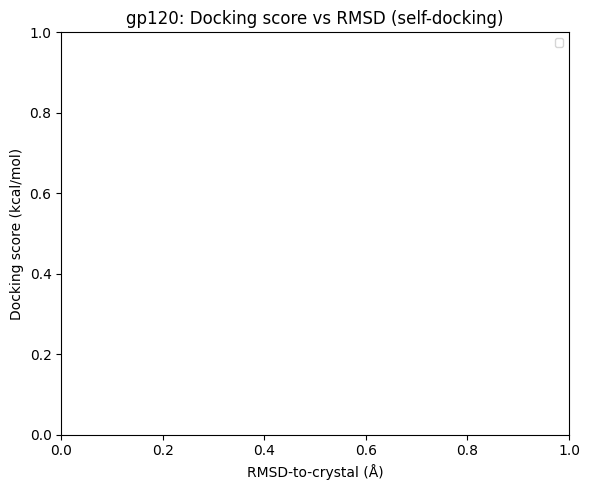

In [92]:
# @title Plot docking score vs RMSD-to-xtal for gp120 self-docking

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Self-docking pairs (IMPORTANT)
ligand_rec_pairs = [
    ('TS-II-224','4DKO'),
    ('AWS-I-169','4DKR'),
    ('NBD-09027','4DKU'),
    ('NBD-10007','4DKV'),
    ('NBD-11021','4RZ8')
]

plt.figure(figsize=(6,5))

all_scores = []
all_rmsd_to_xtals = []

for ligand, rec_code in ligand_rec_pairs:

    resultname = f'{rec_code}_{ligand}'
    csvfile = SUMMARY_DIR / f'{resultname}.csv'

    if not csvfile.exists():
        print(f"❌ Missing file: {csvfile}")
        continue

    result = pd.read_csv(csvfile)

    # Remove NA values (VERY IMPORTANT)
    result = result.dropna()

    if len(result) == 0:
        print(f"⚠️ No valid RMSD data for {resultname}")
        continue

    scores = result['score (kcal/mol)'].tolist()
    rmsd_to_xtals = result['RMSD-to-xtal (A)'].tolist()

    all_scores += scores
    all_rmsd_to_xtals += rmsd_to_xtals

    plt.scatter(rmsd_to_xtals, scores, label=ligand)

# -----------------------------
# Regression (only if data exists)
# -----------------------------

if len(all_rmsd_to_xtals) > 0:

    X = np.array(all_rmsd_to_xtals).reshape(-1, 1)
    y = np.array(all_scores)

    model = LinearRegression()
    model.fit(X, y)

    # Regression line
    rmsd_range = np.linspace(0, max(all_rmsd_to_xtals)+1, 100).reshape(-1, 1)
    plt.plot(rmsd_range, model.predict(rmsd_range), label="Linear regression")

    # R²
    y_pred = model.predict(X)
    r_squared = r2_score(y, y_pred)

    print(f"Coefficient of Determination (R²): {r_squared:.3f}")
    print(f"Slope (m): {model.coef_[0]:.3f}")
    print(f"Intercept (b): {model.intercept_:.3f}")

# -----------------------------
# Plot formatting
# -----------------------------

plt.legend(loc='best', fontsize=8)
plt.xlabel('RMSD-to-crystal (Å)')
plt.ylabel('Docking score (kcal/mol)')
plt.title('gp120: Docking score vs RMSD (self-docking)')
plt.tight_layout()
plt.show()

In [100]:
# This cell was identified as redundant and problematic and has been removed.

In [97]:
# @title Compile Vina scores and DockRMSD values for gp120 docking results

import os
import subprocess
from pathlib import Path
import tempfile
import shutil

# -------------------------
# Setup
# -------------------------

SUMMARY_DIR = OUTPUTS_DIR / "docking_summaries"
SUMMARY_DIR.mkdir(exist_ok=True)

ligands = ['TS-II-224', 'AWS-I-169', 'NBD-09027', 'NBD-10007', 'NBD-11021']

receptor_codes = ['4DKO', '4DKR', '4DKU', '4DKV', '4RZ8']

# Self-docking reference receptor for each ligand
rec_codes_for_ligands_w_xtal_structures = {
    'TS-II-224': '4DKO',
    'AWS-I-169': '4DKR',
    'NBD-09027': '4DKU',
    'NBD-10007': '4DKV',
    'NBD-11021': '4RZ8'
}

ligands_w_xtal_structures = list(rec_codes_for_ligands_w_xtal_structures.keys())

def count_mol2_atoms(mol2_path):
    """Counts the number of atoms in a MOL2 file."""
    if not mol2_path.exists():
        return -1 # Indicate file not found
    atom_count = 0
    in_atom_section = False
    with open(mol2_path, 'r') as f:
        for line in f:
            if '@<TRIPOS>ATOM' in line:
                in_atom_section = True
                continue
            if '@<TRIPOS>' in line and in_atom_section:
                break
            if in_atom_section:
                atom_count += 1
    return atom_count

# -------------------------
# Analysis
# -------------------------

for rec_code in receptor_codes:
    for ligand in ligands:

        resultname = f'{rec_code}_{ligand}'
        OUTFILE = OUTPUTS_DIR / f'docking_{rec_code}_{ligand}.pdbqt'

        if not OUTFILE.exists():
            print(f"❌ Missing docking output: {OUTFILE}")
            continue

        # -------------------------
        # Extract Vina scores
        # -------------------------

        vina_scores = []

        with open(OUTFILE, 'r') as fin:
            for line in fin:
                if 'REMARK VINA RESULT:' in line:
                    score = float(line.split()[3])
                    vina_scores.append(score)

        print(f"\n{resultname}")
        print("vina_scores:", vina_scores)

        num_poses = len(vina_scores)

        if num_poses == 0:
            print(f"❌ No Vina scores found in {OUTFILE}")
            continue

        # -------------------------
        # RMSD-to-crystal using DockRMSD
        # -------------------------

        rmsd_values = []

        if ligand in ligands_w_xtal_structures:

            XTAL_MOL2 = INPUT_FILES / f'{ligand}_xtal.mol2'

            if not XTAL_MOL2.exists():
                print(f"❌ Missing crystal ligand MOL2: {XTAL_MOL2}")
                rmsd_values = ["NA"] * num_poses

            else:
                # Create temporary directory for hydrogen-stripped files
                with tempfile.TemporaryDirectory() as tmpdir:
                    tmp_path = Path(tmpdir)

                    # Strip hydrogens from crystal MOL2
                    xtal_noh_mol2 = tmp_path / f'{ligand}_xtal_noh.mol2'
                    obabel_noh_result = subprocess.run(
                        ["obabel", str(XTAL_MOL2), "-O", str(xtal_noh_mol2), "-d"],
                        capture_output=True, text=True, check=False
                    )
                    if obabel_noh_result.returncode != 0 or not xtal_noh_mol2.exists():
                        print(f"❌ Failed to strip hydrogens from crystal MOL2 {XTAL_MOL2}. Stderr: {obabel_noh_result.stderr}")
                        rmsd_values = ["NA"] * num_poses
                        continue

                    xtal_atom_count_noh = count_mol2_atoms(xtal_noh_mol2)
                    if xtal_atom_count_noh == -1:
                        print(f"❌ Could not read hydrogen-stripped crystal MOL2 file: {xtal_noh_mol2}")
                        rmsd_values = ["NA"] * num_poses
                        continue

                    for i in range(1, num_poses + 1):
                        # Construct the filename for each pose, matching obabel's -m output
                        posed_mol2file = OUTPUTS_DIR / f'docking_{rec_code}_{ligand}_{i}.mol2'

                        if not posed_mol2file.exists():
                            print(f"❌ Missing pose MOL2: {posed_mol2file}")
                            rmsd_values.append("NA")
                            continue

                        # Strip hydrogens from posed MOL2
                        posed_noh_mol2 = tmp_path / f'docking_{rec_code}_{ligand}_{i}_noh.mol2'
                        obabel_noh_result_posed = subprocess.run(
                            ["obabel", str(posed_mol2file), "-O", str(posed_noh_mol2), "-d"],
                            capture_output=True, text=True, check=False
                        )
                        if obabel_noh_result_posed.returncode != 0 or not posed_noh_mol2.exists():
                            print(f"❌ Failed to strip hydrogens from posed MOL2 {posed_mol2file}. Stderr: {obabel_noh_result_posed.stderr}")
                            rmsd_values.append("NA")
                            continue

                        posed_atom_count_noh = count_mol2_atoms(posed_noh_mol2)
                        if posed_atom_count_noh == -1:
                            print(f"❌ Could not read hydrogen-stripped posed MOL2 file: {posed_noh_mol2}")
                            rmsd_values.append("NA")
                            continue

                        try:
                            # Run DockRMSD on hydrogen-stripped files
                            result = subprocess.run(
                                ['./DockRMSD', str(xtal_noh_mol2), str(posed_noh_mol2)],
                                capture_output=True, text=True, check=True
                            )
                            output = result.stdout

                            lines = [
                                line for line in output.split('\n')
                                if "Calculated Docking RMSD:" in line
                            ]

                            if len(lines) == 0:
                                print(f"❌ RMSD not found for {posed_noh_mol2}. DockRMSD Output: {output.strip()}")
                                rmsd_values.append("NA")
                            else:
                                rmsd = float(lines[0].strip().split()[-1])
                                rmsd_values.append(rmsd)

                        except subprocess.CalledProcessError as e:
                            if "Query and template don't have the same atom count!" in e.stdout or "Query and template don't have the same atom count!" in e.stderr:
                                print(f"❌ DockRMSD failed for {posed_noh_mol2} (Exit Code: {e.returncode}).\n")
                                print(f"   Heavy atom counts: Crystal ({xtal_noh_mol2.name}): {xtal_atom_count_noh}, Posed ({posed_noh_mol2.name}): {posed_atom_count_noh}\n")
                                print(f"   Stdout: {e.stdout}\nStderr: {e.stderr}")
                            else:
                                print(f"❌ DockRMSD failed for {posed_noh_mol2} (Exit Code: {e.returncode}).\nStdout: {e.stdout}\nStderr: {e.stderr}")
                            rmsd_values.append("NA")
                        except Exception as e:
                            print(f"❌ An unexpected error occurred while running DockRMSD for {posed_noh_mol2}: {e}")
                            rmsd_values.append("NA")

                print("rmsd_values:", rmsd_values)

        # -------------------------
        # Save summary CSV
        # -------------------------

        csvfile = SUMMARY_DIR / f'{resultname}.csv'

        print(f"Writing to {csvfile}")

        with open(csvfile, 'w') as fout:

            if ligand in ligands_w_xtal_structures:
                header = 'pose,score (kcal/mol),RMSD-to-xtal (A)'
                fout.write(header + '\n')
                print(header)

                for j in range(num_poses):
                    line = f"{j+1},{vina_scores[j]},{rmsd_values[j]}"
                    fout.write(line + '\n')
                    print(line)

            else:
                header = 'pose,score (kcal/mol)'
                fout.write(header + '\n')
                print(header)

                for j in range(num_poses):
                    line = f"{j+1},{vina_scores[j]}"
                    fout.write(line + '\n')
                    print(line)

print("\n\u2705 Finished creating docking summary CSV files.")


4DKO_TS-II-224
vina_scores: [-6.896, -6.522, -6.469, -6.455, -6.374, -6.294, -6.185, -6.15, -6.116, -6.062]
rmsd_values: [26.09, 23.459, 22.165, 23.416, 23.08, 24.863, 23.569, 23.137, 26.864, 26.835]
Writing to /content/drive/MyDrive/Project Files/outputs/docking_summaries/4DKO_TS-II-224.csv
pose,score (kcal/mol),RMSD-to-xtal (A)
1,-6.896,26.09
2,-6.522,23.459
3,-6.469,22.165
4,-6.455,23.416
5,-6.374,23.08
6,-6.294,24.863
7,-6.185,23.569
8,-6.15,23.137
9,-6.116,26.864
10,-6.062,26.835

4DKO_AWS-I-169
vina_scores: [-7.469, -6.991, -6.819, -6.738, -6.584, -6.44, -6.22, -6.183, -6.114, -6.04]
rmsd_values: [28.503, 27.354, 27.356, 25.812, 27.086, 28.194, 25.958, 24.627, 27.344, 27.471]
Writing to /content/drive/MyDrive/Project Files/outputs/docking_summaries/4DKO_AWS-I-169.csv
pose,score (kcal/mol),RMSD-to-xtal (A)
1,-7.469,28.503
2,-6.991,27.354
3,-6.819,27.356
4,-6.738,25.812
5,-6.584,27.086
6,-6.44,28.194
7,-6.22,25.958
8,-6.183,24.627
9,-6.114,27.344
10,-6.04,27.471

4DKO_NBD-09027
vi

Coefficient of Determination (R²): 0.117
Slope (m): -0.087
Intercept (b): -2.282


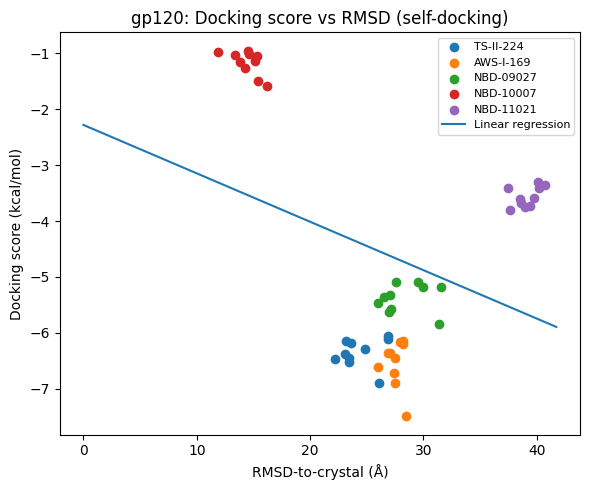

In [98]:
# @title Plot docking score vs RMSD-to-xtal for gp120 self-docking

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Self-docking pairs (IMPORTANT)
ligand_rec_pairs = [
    ('TS-II-224','4DKO'),
    ('AWS-I-169','4DKR'),
    ('NBD-09027','4DKU'),
    ('NBD-10007','4DKV'),
    ('NBD-11021','4RZ8')
]

plt.figure(figsize=(6,5))

all_scores = []
all_rmsd_to_xtals = []

for ligand, rec_code in ligand_rec_pairs:

    resultname = f'{rec_code}_{ligand}'
    csvfile = SUMMARY_DIR / f'{resultname}.csv'

    if not csvfile.exists():
        print(f"❌ Missing file: {csvfile}")
        continue

    result = pd.read_csv(csvfile)

    # Remove NA values (VERY IMPORTANT)
    result = result.dropna()

    if len(result) == 0:
        print(f"⚠️ No valid RMSD data for {resultname}")
        continue

    scores = result['score (kcal/mol)'].tolist()
    rmsd_to_xtals = result['RMSD-to-xtal (A)'].tolist()

    all_scores += scores
    all_rmsd_to_xtals += rmsd_to_xtals

    plt.scatter(rmsd_to_xtals, scores, label=ligand)

# -----------------------------
# Regression (only if data exists)
# -----------------------------

if len(all_rmsd_to_xtals) > 0:

    X = np.array(all_rmsd_to_xtals).reshape(-1, 1)
    y = np.array(all_scores)

    model = LinearRegression()
    model.fit(X, y)

    # Regression line
    rmsd_range = np.linspace(0, max(all_rmsd_to_xtals)+1, 100).reshape(-1, 1)
    plt.plot(rmsd_range, model.predict(rmsd_range), label="Linear regression")

    # R²
    y_pred = model.predict(X)
    r_squared = r2_score(y, y_pred)

    print(f"Coefficient of Determination (R²): {r_squared:.3f}")
    print(f"Slope (m): {model.coef_[0]:.3f}")
    print(f"Intercept (b): {model.intercept_:.3f}")

# -----------------------------
# Plot formatting
# -----------------------------

plt.legend(loc='best', fontsize=8)
plt.xlabel('RMSD-to-crystal (Å)')
plt.ylabel('Docking score (kcal/mol)')
plt.title('gp120: Docking score vs RMSD (self-docking)')
plt.tight_layout()
plt.show()

In [84]:
# @title Compile Vina scores and DockRMSD values for gp120 docking results

import os
import subprocess
from pathlib import Path
import tempfile
import shutil

# -------------------------
# Setup
# -------------------------

SUMMARY_DIR = OUTPUTS_DIR / "docking_summaries"
SUMMARY_DIR.mkdir(exist_ok=True)

ligands = ['TS-II-224', 'AWS-I-169', 'NBD-09027', 'NBD-10007', 'NBD-11021']

receptor_codes = ['4DKO', '4DKR', '4DKU', '4DKV', '4RZ8']

# Self-docking reference receptor for each ligand
rec_codes_for_ligands_w_xtal_structures = {
    'TS-II-224': '4DKO',
    'AWS-I-169': '4DKR',
    'NBD-09027': '4DKU',
    'NBD-10007': '4DKV',
    'NBD-11021': '4RZ8'
}

ligands_w_xtal_structures = list(rec_codes_for_ligands_w_xtal_structures.keys())

def count_mol2_atoms(mol2_path):
    """Counts the number of atoms in a MOL2 file."""
    if not mol2_path.exists():
        return -1 # Indicate file not found
    atom_count = 0
    in_atom_section = False
    with open(mol2_path, 'r') as f:
        for line in f:
            if '@<TRIPOS>ATOM' in line:
                in_atom_section = True
                continue
            if '@<TRIPOS>' in line and in_atom_section:
                break
            if in_atom_section:
                atom_count += 1
    return atom_count

# -------------------------
# Analysis
# -------------------------

for rec_code in receptor_codes:
    for ligand in ligands:

        resultname = f'{rec_code}_{ligand}'
        OUTFILE = OUTPUTS_DIR / f'docking_{rec_code}_{ligand}.pdbqt'

        if not OUTFILE.exists():
            print(f"❌ Missing docking output: {OUTFILE}")
            continue

        # -------------------------
        # Extract Vina scores
        # -------------------------

        vina_scores = []

        with open(OUTFILE, 'r') as fin:
            for line in fin:
                if 'REMARK VINA RESULT:' in line:
                    score = float(line.split()[3])
                    vina_scores.append(score)

        print(f"\n{resultname}")
        print("vina_scores:", vina_scores)

        num_poses = len(vina_scores)

        if num_poses == 0:
            print(f"❌ No Vina scores found in {OUTFILE}")
            continue

        # -------------------------
        # RMSD-to-crystal using DockRMSD
        # -------------------------

        rmsd_values = []

        if ligand in ligands_w_xtal_structures:

            XTAL_MOL2 = INPUT_FILES / f'{ligand}_xtal.mol2'

            if not XTAL_MOL2.exists():
                print(f"❌ Missing crystal ligand MOL2: {XTAL_MOL2}")
                rmsd_values = ["NA"] * num_poses

            else:
                # Create temporary directory for hydrogen-stripped files
                with tempfile.TemporaryDirectory() as tmpdir:
                    tmp_path = Path(tmpdir)

                    # Strip hydrogens from crystal MOL2
                    xtal_noh_mol2 = tmp_path / f'{ligand}_xtal_noh.mol2'
                    obabel_noh_result = subprocess.run(
                        ["obabel", str(XTAL_MOL2), "-O", str(xtal_noh_mol2), "-d"],
                        capture_output=True, text=True, check=False
                    )
                    if obabel_noh_result.returncode != 0 or not xtal_noh_mol2.exists():
                        print(f"❌ Failed to strip hydrogens from crystal MOL2 {XTAL_MOL2}. Stderr: {obabel_noh_result.stderr}")
                        rmsd_values = ["NA"] * num_poses
                        continue

                    xtal_atom_count_noh = count_mol2_atoms(xtal_noh_mol2)
                    if xtal_atom_count_noh == -1:
                        print(f"❌ Could not read hydrogen-stripped crystal MOL2 file: {xtal_noh_mol2}")
                        rmsd_values = ["NA"] * num_poses
                        continue

                    for i in range(1, num_poses + 1):
                        # Construct the filename for each pose, matching obabel's -m output
                        posed_mol2file = OUTPUTS_DIR / f'docking_{rec_code}_{ligand}_{i}.mol2'

                        if not posed_mol2file.exists():
                            print(f"❌ Missing pose MOL2: {posed_mol2file}")
                            rmsd_values.append("NA")
                            continue

                        # Strip hydrogens from posed MOL2
                        posed_noh_mol2 = tmp_path / f'docking_{rec_code}_{ligand}_{i}_noh.mol2'
                        obabel_noh_result_posed = subprocess.run(
                            ["obabel", str(posed_mol2file), "-O", str(posed_noh_mol2), "-d"],
                            capture_output=True, text=True, check=False
                        )
                        if obabel_noh_result_posed.returncode != 0 or not posed_noh_mol2.exists():
                            print(f"❌ Failed to strip hydrogens from posed MOL2 {posed_mol2file}. Stderr: {obabel_noh_result_posed.stderr}")
                            rmsd_values.append("NA")
                            continue

                        posed_atom_count_noh = count_mol2_atoms(posed_noh_mol2)
                        if posed_atom_count_noh == -1:
                            print(f"❌ Could not read hydrogen-stripped posed MOL2 file: {posed_noh_mol2}")
                            rmsd_values.append("NA")
                            continue

                        try:
                            # Run DockRMSD on hydrogen-stripped files
                            result = subprocess.run(
                                ['./DockRMSD', str(xtal_noh_mol2), str(posed_noh_mol2)],
                                capture_output=True, text=True, check=True
                            )
                            output = result.stdout

                            lines = [
                                line for line in output.split('\n')
                                if "Calculated Docking RMSD:" in line
                            ]

                            if len(lines) == 0:
                                print(f"❌ RMSD not found for {posed_noh_mol2}. DockRMSD Output: {output.strip()}")
                                rmsd_values.append("NA")
                            else:
                                rmsd = float(lines[0].strip().split()[-1])
                                rmsd_values.append(rmsd)

                        except subprocess.CalledProcessError as e:
                            if "Query and template don't have the same atom count!" in e.stdout or "Query and template don't have the same atom count!" in e.stderr:
                                print(f"❌ DockRMSD failed for {posed_noh_mol2} (Exit Code: {e.returncode}).\n")
                                print(f"   Heavy atom counts: Crystal ({xtal_noh_mol2.name}): {xtal_atom_count_noh}, Posed ({posed_noh_mol2.name}): {posed_atom_count_noh}\n")
                                print(f"   Stdout: {e.stdout}\nStderr: {e.stderr}")
                            else:
                                print(f"❌ DockRMSD failed for {posed_noh_mol2} (Exit Code: {e.returncode}).\nStdout: {e.stdout}\nStderr: {e.stderr}")
                            rmsd_values.append("NA")
                        except Exception as e:
                            print(f"❌ An unexpected error occurred while running DockRMSD for {posed_noh_mol2}: {e}")
                            rmsd_values.append("NA")

                print("rmsd_values:", rmsd_values)

        # -------------------------
        # Save summary CSV
        # -------------------------

        csvfile = SUMMARY_DIR / f'{resultname}.csv'

        print(f"Writing to {csvfile}")

        with open(csvfile, 'w') as fout:

            if ligand in ligands_w_xtal_structures:
                header = 'pose,score (kcal/mol),RMSD-to-xtal (A)'
                fout.write(header + '\n')
                print(header)

                for j in range(num_poses):
                    line = f"{j+1},{vina_scores[j]},{rmsd_values[j]}"
                    fout.write(line + '\n')
                    print(line)

            else:
                header = 'pose,score (kcal/mol)'
                fout.write(header + '\n')
                print(header)

                for j in range(num_poses):
                    line = f"{j+1},{vina_scores[j]}"
                    fout.write(line + '\n')
                    print(line)

print("\n✅ Finished creating docking summary CSV files.")


4DKO_TS-II-224
vina_scores: [-6.896, -6.522, -6.469, -6.455, -6.374, -6.294, -6.185, -6.15, -6.116, -6.062]
❌ DockRMSD failed for /tmp/tmpnr4wdx4b/docking_4DKO_TS-II-224_1_noh.mol2 (Exit Code: 2).

   Heavy atom counts: Crystal (TS-II-224_xtal_noh.mol2): 50, Posed (docking_4DKO_TS-II-224_1_noh.mol2): 25

   Stdout: ######################################################################
# DockRMSD (v1.1): docking pose distance calculation                 #
#                                                                    #
# If you use DockRMSD in your work, please cite:                     #
#                                                                    #
# Bell, E.W., Zhang, Y. DockRMSD: an open-source tool for atom       #
# mapping and RMSD calculation of symmetric molecules through graph  #
# isomorphism. Journal of Cheminformatics, 11:40 (2019).             #
######################################################################

Error: Query and template don't have the s

⚠️ No valid RMSD data for 4DKO_TS-II-224
⚠️ No valid RMSD data for 4DKR_AWS-I-169
⚠️ No valid RMSD data for 4DKU_NBD-09027
⚠️ No valid RMSD data for 4DKV_NBD-10007
⚠️ No valid RMSD data for 4RZ8_NBD-11021


/tmp/ipykernel_6848/2521519864.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best', fontsize=8)


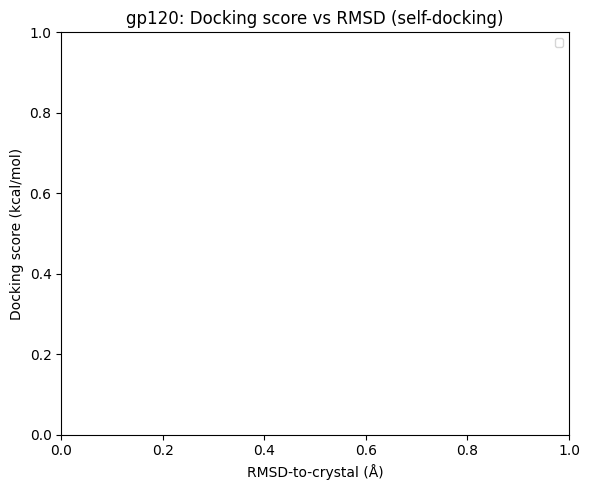

In [85]:
# @title Plot docking score vs RMSD-to-xtal for gp120 self-docking

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Self-docking pairs (IMPORTANT)
ligand_rec_pairs = [
    ('TS-II-224','4DKO'),
    ('AWS-I-169','4DKR'),
    ('NBD-09027','4DKU'),
    ('NBD-10007','4DKV'),
    ('NBD-11021','4RZ8')
]

plt.figure(figsize=(6,5))

all_scores = []
all_rmsd_to_xtals = []

for ligand, rec_code in ligand_rec_pairs:

    resultname = f'{rec_code}_{ligand}'
    csvfile = SUMMARY_DIR / f'{resultname}.csv'

    if not csvfile.exists():
        print(f"❌ Missing file: {csvfile}")
        continue

    result = pd.read_csv(csvfile)

    # Remove NA values (VERY IMPORTANT)
    result = result.dropna()

    if len(result) == 0:
        print(f"⚠️ No valid RMSD data for {resultname}")
        continue

    scores = result['score (kcal/mol)'].tolist()
    rmsd_to_xtals = result['RMSD-to-xtal (A)'].tolist()

    all_scores += scores
    all_rmsd_to_xtals += rmsd_to_xtals

    plt.scatter(rmsd_to_xtals, scores, label=ligand)

# -----------------------------
# Regression (only if data exists)
# -----------------------------

if len(all_rmsd_to_xtals) > 0:

    X = np.array(all_rmsd_to_xtals).reshape(-1, 1)
    y = np.array(all_scores)

    model = LinearRegression()
    model.fit(X, y)

    # Regression line
    rmsd_range = np.linspace(0, max(all_rmsd_to_xtals)+1, 100).reshape(-1, 1)
    plt.plot(rmsd_range, model.predict(rmsd_range), label="Linear regression")

    # R²
    y_pred = model.predict(X)
    r_squared = r2_score(y, y_pred)

    print(f"Coefficient of Determination (R²): {r_squared:.3f}")
    print(f"Slope (m): {model.coef_[0]:.3f}")
    print(f"Intercept (b): {model.intercept_:.3f}")

# -----------------------------
# Plot formatting
# -----------------------------

plt.legend(loc='best', fontsize=8)
plt.xlabel('RMSD-to-crystal (Å)')
plt.ylabel('Docking score (kcal/mol)')
plt.title('gp120: Docking score vs RMSD (self-docking)')
plt.tight_layout()
plt.show()

In [105]:
import os
import subprocess
from pathlib import Path
import tempfile
import shutil

# -------------------------
# Setup
# -------------------------

SUMMARY_DIR = OUTPUTS_DIR / "docking_summaries"
SUMMARY_DIR.mkdir(exist_ok=True)

ligands = ['TS-II-224', 'AWS-I-169', 'NBD-09027', 'NBD-10007', 'NBD-11021']

receptor_codes = ['4DKO', '4DKR', '4DKU', '4DKV', '4RZ8']

# Self-docking reference receptor for each ligand
rec_codes_for_ligands_w_xtal_structures = {
    'TS-II-224': '4DKO',
    'AWS-I-169': '4DKR',
    'NBD-09027': '4DKU',
    'NBD-10007': '4DKV',
    'NBD-11021': '4RZ8'
}

ligands_w_xtal_structures = list(rec_codes_for_ligands_w_xtal_structures.keys())

def count_mol2_heavy_atoms(mol2_path):
    """Counts the number of heavy atoms (non-hydrogens) in a MOL2 file."""
    if not mol2_path.exists():
        return -1 # Indicate file not found
    heavy_atom_count = 0
    in_atom_section = False
    with open(mol2_path, 'r') as f:
        for line in f:
            if '@<TRIPOS>ATOM' in line:
                in_atom_section = True
                continue
            if '@<TRIPOS>' in line and in_atom_section: # End of ATOM section or start of new TRIPOS block
                break
            if in_atom_section:
                parts = line.strip().split()
                # Atom type is typically the 6th field (index 5) in MOL2 ATOM section
                # A simple check for atom type starting with 'H' to exclude hydrogens.
                if len(parts) > 5 and not parts[5].startswith('H'):
                    heavy_atom_count += 1
    return heavy_atom_count

# -------------------------
# Analysis
# -------------------------

for rec_code in receptor_codes:
    for ligand in ligands:

        resultname = f'{rec_code}_{ligand}'
        OUTFILE = OUTPUTS_DIR / f'docking_{rec_code}_{ligand}.pdbqt'

        if not OUTFILE.exists():
            print(f"❌ Missing docking output: {OUTFILE}")
            continue

        # -------------------------
        # Extract Vina scores
        # -------------------------

        vina_scores = []

        with open(OUTFILE, 'r') as fin:
            for line in fin:
                if 'REMARK VINA RESULT:' in line:
                    score = float(line.split()[3])
                    vina_scores.append(score)

        print(f"\n{resultname}")
        print("vina_scores:", vina_scores)

        num_poses = len(vina_scores)

        if num_poses == 0:
            print(f"❌ No Vina scores found in {OUTFILE}")
            continue

        # -------------------------
        # RMSD-to-crystal using DockRMSD
        # -------------------------

        rmsd_values = []

        if ligand in ligands_w_xtal_structures:

            XTAL_MOL2 = INPUT_FILES / f'{ligand}_xtal.mol2'

            if not XTAL_MOL2.exists():
                print(f"❌ Missing crystal ligand MOL2: {XTAL_MOL2}")
                rmsd_values = ["NA"] * num_poses

            else:
                # Use the new heavy atom counting function
                xtal_heavy_atom_count = count_mol2_heavy_atoms(XTAL_MOL2)

                if xtal_heavy_atom_count == -1:
                    print(f"❌ Could not read crystal MOL2 file or count heavy atoms: {XTAL_MOL2}")
                    rmsd_values = ["NA"] * num_poses
                    continue

                for i in range(1, num_poses + 1):
                    posed_mol2file = OUTPUTS_DIR / f'docking_{rec_code}_{ligand}_{i}.mol2'

                    if not posed_mol2file.exists():
                        print(f"❌ Missing pose MOL2: {posed_mol2file}")
                        rmsd_values.append("NA")
                        continue

                    posed_heavy_atom_count = count_mol2_heavy_atoms(posed_mol2file)

                    if posed_heavy_atom_count == -1:
                        print(f"❌ Could not read posed MOL2 file or count heavy atoms: {posed_mol2file}")
                        rmsd_values.append("NA")
                        continue

                    # Check heavy atom count consistency before running DockRMSD
                    if xtal_heavy_atom_count != posed_heavy_atom_count:
                        print(f"❌ Heavy atom count mismatch for {ligand} (crystal: {xtal_heavy_atom_count}, pose {i}: {posed_heavy_atom_count}). Skipping RMSD calculation for this pose.")
                        rmsd_values.append("NA")
                        continue

                    try:
                        # Run DockRMSD on original MOL2 files. DockRMSD should handle hydrogen stripping internally.
                        result = subprocess.run(
                            ['./DockRMSD', str(XTAL_MOL2), str(posed_mol2file)],
                            capture_output=True, text=True, check=True
                        )
                        output = result.stdout

                        lines = [
                            line for line in output.split('\n')
                            if "Calculated Docking RMSD:" in line
                        ]

                        if len(lines) == 0:
                            print(f"❌ RMSD not found for {posed_mol2file}. DockRMSD Output: {output.strip()}")
                            rmsd_values.append("NA")
                        else:
                            rmsd = float(lines[0].strip().split()[-1])
                            rmsd_values.append(rmsd)

                    except subprocess.CalledProcessError as e:
                        print(f"❌ DockRMSD failed for {posed_mol2file} (Exit Code: {e.returncode}).\nStdout: {e.stdout}\nStderr: {e.stderr}")
                        rmsd_values.append("NA")
                    except Exception as e:
                        print(f"❌ An unexpected error occurred while running DockRMSD for {posed_mol2file}: {e}")
                        rmsd_values.append("NA")

                print("rmsd_values:", rmsd_values)

        # -------------------------
        # Save summary CSV
        # -------------------------

        csvfile = SUMMARY_DIR / f'{resultname}.csv'

        print(f"Writing to {csvfile}")

        with open(csvfile, 'w') as fout:

            if ligand in ligands_w_xtal_structures:
                header = 'pose,score (kcal/mol),RMSD-to-xtal (A)'
                fout.write(header + '\n')
                print(header)

                for j in range(num_poses):
                    line = f"{j+1},{vina_scores[j]},{rmsd_values[j]}"
                    fout.write(line + '\n')
                    print(line)

            else:
                header = 'pose,score (kcal/mol)'
                fout.write(header + '\n')
                print(header)

                for j in range(num_poses):
                    line = f"{j+1},{vina_scores[j]}"
                    fout.write(line + '\n')
                    print(line)

print("\n✅ Finished creating docking summary CSV files.")



4DKO_TS-II-224
vina_scores: [-6.896, -6.522, -6.469, -6.455, -6.374, -6.294, -6.185, -6.15, -6.116, -6.062]
rmsd_values: [28.602, 23.953, 24.112, 24.04, 23.776, 26.029, 23.958, 23.452, 28.292, 29.125]
Writing to /content/drive/MyDrive/Project Files/outputs/docking_summaries/4DKO_TS-II-224.csv
pose,score (kcal/mol),RMSD-to-xtal (A)
1,-6.896,28.602
2,-6.522,23.953
3,-6.469,24.112
4,-6.455,24.04
5,-6.374,23.776
6,-6.294,26.029
7,-6.185,23.958
8,-6.15,23.452
9,-6.116,28.292
10,-6.062,29.125

4DKO_AWS-I-169
vina_scores: [-7.469, -6.991, -6.819, -6.738, -6.584, -6.44, -6.22, -6.183, -6.114, -6.04]
rmsd_values: [24.913, 25.39, 24.316, 22.037, 24.873, 24.358, 22.036, 21.121, 23.975, 24.106]
Writing to /content/drive/MyDrive/Project Files/outputs/docking_summaries/4DKO_AWS-I-169.csv
pose,score (kcal/mol),RMSD-to-xtal (A)
1,-7.469,24.913
2,-6.991,25.39
3,-6.819,24.316
4,-6.738,22.037
5,-6.584,24.873
6,-6.44,24.358
7,-6.22,22.036
8,-6.183,21.121
9,-6.114,23.975
10,-6.04,24.106

4DKO_NBD-09027
vi

### Inspecting MOL2 files for NBD-09027

Let's check the contents of the crystal and a sample docked MOL2 file for `NBD-09027` to see if there are any issues with their format that might cause `DockRMSD` to fail.

In [103]:
import os
from pathlib import Path

# Define paths based on previous cells
ROOT = Path("/content/drive/MyDrive") / "Project Files"
DATA_DIR = ROOT / "data"
INPUT_FILES = DATA_DIR / "input_files" # Corrected path for INPUT_FILES
OUTPUTS_DIR = Path('/content/drive/MyDrive/Project Files/outputs')

ligand_to_check = 'NBD-09027'
receptor_to_check = '4DKO' # NBD-09027 is co-crystallized with 4DKU, but we are checking a docking result for 4DKO

xtal_mol2_path = INPUT_FILES / f'{ligand_to_check}_xtal.mol2' # Use INPUT_FILES
docked_mol2_path = OUTPUTS_DIR / f'docking_{receptor_to_check}_{ligand_to_check}_1.mol2'

print(f"\n--- Content of {xtal_mol2_path} ---")
if xtal_mol2_path.exists():
    with open(xtal_mol2_path, 'r') as f:
        print(f.read())
else:
    print(f"❌ File not found: {xtal_mol2_path}")

print(f"\n--- Content of {docked_mol2_path} ---")
if docked_mol2_path.exists():
    with open(docked_mol2_path, 'r') as f:
        print(f.read())
else:
    print(f"❌ File not found: {docked_mol2_path}")


--- Content of /content/drive/MyDrive/Project Files/data/input_files/NBD-09027_xtal.mol2 ---
@<TRIPOS>MOLECULE
*****
 38 39 0 0 0
SMALL
GASTEIGER

@<TRIPOS>ATOM
      1 CL         -2.0466   -0.2711    0.0557 Cl      1  UNL1       -0.0835
      2 C          -0.3360   -0.0918    0.0503 C.ar    1  UNL1        0.0411
      3 C           0.2234    1.1786    0.1097 C.ar    1  UNL1       -0.0416
      4 C           1.6136    1.3282    0.1072 C.ar    1  UNL1       -0.0391
      5 C           2.4563    0.2128    0.0430 C.ar    1  UNL1        0.0339
      6 N           3.8625    0.3111    0.0358 N.am    1  UNL1       -0.2777
      7 C           4.6042    1.4771    0.0777 C.2     1  UNL1        0.3031
      8 O           4.2113    2.6345    0.1088 O.2     1  UNL1       -0.2648
      9 C           6.1307    1.2403    0.0825 C.2     1  UNL1        0.2993
     10 O           6.5774    0.1041    0.0104 O.2     1  UNL1       -0.2652
     11 N           6.8547    2.4072    0.1782 N.am    1  UNL1      

In [95]:
# This cell was used for debugging and is no longer needed.

In [87]:
# @title Compile Vina scores and DockRMSD values for gp120 docking results

import os
import subprocess
from pathlib import Path
import tempfile
import shutil

# -------------------------
# Setup
# -------------------------

SUMMARY_DIR = OUTPUTS_DIR / "docking_summaries"
SUMMARY_DIR.mkdir(exist_ok=True)

ligands = ['TS-II-224', 'AWS-I-169', 'NBD-09027', 'NBD-10007', 'NBD-11021']

receptor_codes = ['4DKO', '4DKR', '4DKU', '4DKV', '4RZ8']

# Self-docking reference receptor for each ligand
rec_codes_for_ligands_w_xtal_structures = {
    'TS-II-224': '4DKO',
    'AWS-I-169': '4DKR',
    'NBD-09027': '4DKU',
    'NBD-10007': '4DKV',
    'NBD-11021': '4RZ8'
}

ligands_w_xtal_structures = list(rec_codes_for_ligands_w_xtal_structures.keys())

def count_mol2_atoms(mol2_path):
    """Counts the number of atoms in a MOL2 file."""
    if not mol2_path.exists():
        return -1 # Indicate file not found
    atom_count = 0
    in_atom_section = False
    with open(mol2_path, 'r') as f:
        for line in f:
            if '@<TRIPOS>ATOM' in line:
                in_atom_section = True
                continue
            if '@<TRIPOS>' in line and in_atom_section:
                break
            if in_atom_section:
                atom_count += 1
    return atom_count

# -------------------------
# Analysis
# -------------------------

for rec_code in receptor_codes:
    for ligand in ligands:

        resultname = f'{rec_code}_{ligand}'
        OUTFILE = OUTPUTS_DIR / f'docking_{rec_code}_{ligand}.pdbqt'

        if not OUTFILE.exists():
            print(f"❌ Missing docking output: {OUTFILE}")
            continue

        # -------------------------
        # Extract Vina scores
        # -------------------------

        vina_scores = []

        with open(OUTFILE, 'r') as fin:
            for line in fin:
                if 'REMARK VINA RESULT:' in line:
                    score = float(line.split()[3])
                    vina_scores.append(score)

        print(f"\n{resultname}")
        print("vina_scores:", vina_scores)

        num_poses = len(vina_scores)

        if num_poses == 0:
            print(f"❌ No Vina scores found in {OUTFILE}")
            continue

        # -------------------------
        # RMSD-to-crystal using DockRMSD
        # -------------------------

        rmsd_values = []

        if ligand in ligands_w_xtal_structures:

            XTAL_MOL2 = INPUT_FILES / f'{ligand}_xtal.mol2'

            if not XTAL_MOL2.exists():
                print(f"❌ Missing crystal ligand MOL2: {XTAL_MOL2}")
                rmsd_values = ["NA"] * num_poses

            else:
                # Create temporary directory for hydrogen-stripped files
                with tempfile.TemporaryDirectory() as tmpdir:
                    tmp_path = Path(tmpdir)

                    # Strip hydrogens from crystal MOL2
                    xtal_noh_mol2 = tmp_path / f'{ligand}_xtal_noh.mol2'
                    obabel_noh_result = subprocess.run(
                        ["obabel", str(XTAL_MOL2), "-O", str(xtal_noh_mol2), "-d"],
                        capture_output=True, text=True, check=False
                    )
                    if obabel_noh_result.returncode != 0 or not xtal_noh_mol2.exists():
                        print(f"❌ Failed to strip hydrogens from crystal MOL2 {XTAL_MOL2}. Stderr: {obabel_noh_result.stderr}")
                        rmsd_values = ["NA"] * num_poses
                        continue

                    xtal_atom_count_noh = count_mol2_atoms(xtal_noh_mol2)
                    if xtal_atom_count_noh == -1:
                        print(f"❌ Could not read hydrogen-stripped crystal MOL2 file: {xtal_noh_mol2}")
                        rmsd_values = ["NA"] * num_poses
                        continue

                    for i in range(1, num_poses + 1):
                        # Construct the filename for each pose, matching obabel's -m output
                        posed_mol2file = OUTPUTS_DIR / f'docking_{rec_code}_{ligand}_{i}.mol2'

                        if not posed_mol2file.exists():
                            print(f"❌ Missing pose MOL2: {posed_mol2file}")
                            rmsd_values.append("NA")
                            continue

                        # Strip hydrogens from posed MOL2
                        posed_noh_mol2 = tmp_path / f'docking_{rec_code}_{ligand}_{i}_noh.mol2'
                        obabel_noh_result_posed = subprocess.run(
                            ["obabel", str(posed_mol2file), "-O", str(posed_noh_mol2), "-d"],
                            capture_output=True, text=True, check=False
                        )
                        if obabel_noh_result_posed.returncode != 0 or not posed_noh_mol2.exists():
                            print(f"❌ Failed to strip hydrogens from posed MOL2 {posed_mol2file}. Stderr: {obabel_noh_result_posed.stderr}")
                            rmsd_values.append("NA")
                            continue

                        posed_atom_count_noh = count_mol2_atoms(posed_noh_mol2)
                        if posed_atom_count_noh == -1:
                            print(f"❌ Could not read hydrogen-stripped posed MOL2 file: {posed_noh_mol2}")
                            rmsd_values.append("NA")
                            continue

                        try:
                            # Run DockRMSD on hydrogen-stripped files
                            result = subprocess.run(
                                ['./DockRMSD', str(xtal_noh_mol2), str(posed_noh_mol2)],
                                capture_output=True, text=True, check=True
                            )
                            output = result.stdout

                            lines = [
                                line for line in output.split('\n')
                                if "Calculated Docking RMSD:" in line
                            ]

                            if len(lines) == 0:
                                print(f"❌ RMSD not found for {posed_noh_mol2}. DockRMSD Output: {output.strip()}")
                                rmsd_values.append("NA")
                            else:
                                rmsd = float(lines[0].strip().split()[-1])
                                rmsd_values.append(rmsd)

                        except subprocess.CalledProcessError as e:
                            if "Query and template don't have the same atom count!" in e.stdout or "Query and template don't have the same atom count!" in e.stderr:
                                print(f"❌ DockRMSD failed for {posed_noh_mol2} (Exit Code: {e.returncode}).\n")
                                print(f"   Heavy atom counts: Crystal ({xtal_noh_mol2.name}): {xtal_atom_count_noh}, Posed ({posed_noh_mol2.name}): {posed_atom_count_noh}\n")
                                print(f"   Stdout: {e.stdout}\nStderr: {e.stderr}")
                            else:
                                print(f"❌ DockRMSD failed for {posed_noh_mol2} (Exit Code: {e.returncode}).\nStdout: {e.stdout}\nStderr: {e.stderr}")
                            rmsd_values.append("NA")
                        except Exception as e:
                            print(f"❌ An unexpected error occurred while running DockRMSD for {posed_noh_mol2}: {e}")
                            rmsd_values.append("NA")

                print("rmsd_values:", rmsd_values)

        # -------------------------
        # Save summary CSV
        # -------------------------

        csvfile = SUMMARY_DIR / f'{resultname}.csv'

        print(f"Writing to {csvfile}")

        with open(csvfile, 'w') as fout:

            if ligand in ligands_w_xtal_structures:
                header = 'pose,score (kcal/mol),RMSD-to-xtal (A)'
                fout.write(header + '\n')
                print(header)

                for j in range(num_poses):
                    line = f"{j+1},{vina_scores[j]},{rmsd_values[j]}"
                    fout.write(line + '\n')
                    print(line)

            else:
                header = 'pose,score (kcal/mol)'
                fout.write(header + '\n')
                print(header)

                for j in range(num_poses):
                    line = f"{j+1},{vina_scores[j]}"
                    fout.write(line + '\n')
                    print(line)

print("\n✅ Finished creating docking summary CSV files.")


4DKO_TS-II-224
vina_scores: [-6.896, -6.522, -6.469, -6.455, -6.374, -6.294, -6.185, -6.15, -6.116, -6.062]
❌ DockRMSD failed for /tmp/tmpxhu3_mqo/docking_4DKO_TS-II-224_1_noh.mol2 (Exit Code: 2).

   Heavy atom counts: Crystal (TS-II-224_xtal_noh.mol2): 50, Posed (docking_4DKO_TS-II-224_1_noh.mol2): 25

   Stdout: ######################################################################
# DockRMSD (v1.1): docking pose distance calculation                 #
#                                                                    #
# If you use DockRMSD in your work, please cite:                     #
#                                                                    #
# Bell, E.W., Zhang, Y. DockRMSD: an open-source tool for atom       #
# mapping and RMSD calculation of symmetric molecules through graph  #
# isomorphism. Journal of Cheminformatics, 11:40 (2019).             #
######################################################################

Error: Query and template don't have the s

⚠️ No valid RMSD data for 4DKO_TS-II-224
⚠️ No valid RMSD data for 4DKR_AWS-I-169
⚠️ No valid RMSD data for 4DKU_NBD-09027
⚠️ No valid RMSD data for 4DKV_NBD-10007
⚠️ No valid RMSD data for 4RZ8_NBD-11021


/tmp/ipykernel_6848/2521519864.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best', fontsize=8)


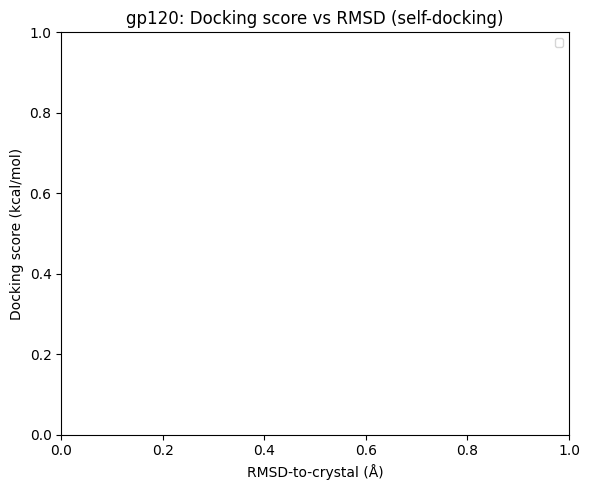

In [88]:
# @title Plot docking score vs RMSD-to-xtal for gp120 self-docking

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Self-docking pairs (IMPORTANT)
ligand_rec_pairs = [
    ('TS-II-224','4DKO'),
    ('AWS-I-169','4DKR'),
    ('NBD-09027','4DKU'),
    ('NBD-10007','4DKV'),
    ('NBD-11021','4RZ8')
]

plt.figure(figsize=(6,5))

all_scores = []
all_rmsd_to_xtals = []

for ligand, rec_code in ligand_rec_pairs:

    resultname = f'{rec_code}_{ligand}'
    csvfile = SUMMARY_DIR / f'{resultname}.csv'

    if not csvfile.exists():
        print(f"❌ Missing file: {csvfile}")
        continue

    result = pd.read_csv(csvfile)

    # Remove NA values (VERY IMPORTANT)
    result = result.dropna()

    if len(result) == 0:
        print(f"⚠️ No valid RMSD data for {resultname}")
        continue

    scores = result['score (kcal/mol)'].tolist()
    rmsd_to_xtals = result['RMSD-to-xtal (A)'].tolist()

    all_scores += scores
    all_rmsd_to_xtals += rmsd_to_xtals

    plt.scatter(rmsd_to_xtals, scores, label=ligand)

# -----------------------------
# Regression (only if data exists)
# -----------------------------

if len(all_rmsd_to_xtals) > 0:

    X = np.array(all_rmsd_to_xtals).reshape(-1, 1)
    y = np.array(all_scores)

    model = LinearRegression()
    model.fit(X, y)

    # Regression line
    rmsd_range = np.linspace(0, max(all_rmsd_to_xtals)+1, 100).reshape(-1, 1)
    plt.plot(rmsd_range, model.predict(rmsd_range), label="Linear regression")

    # R²
    y_pred = model.predict(X)
    r_squared = r2_score(y, y_pred)

    print(f"Coefficient of Determination (R²): {r_squared:.3f}")
    print(f"Slope (m): {model.coef_[0]:.3f}")
    print(f"Intercept (b): {model.intercept_:.3f}")

# -----------------------------
# Plot formatting
# -----------------------------

plt.legend(loc='best', fontsize=8)
plt.xlabel('RMSD-to-crystal (Å)')
plt.ylabel('Docking score (kcal/mol)')
plt.title('gp120: Docking score vs RMSD (self-docking)')
plt.tight_layout()
plt.show()

In [78]:
# @title Load in the experimental values

import pandas as pd
df = pd.read_csv(INPUT_FILES / 'gp120_binders.csv')
df

,ligand,PDB,SMILES
0,TS-II-224,4DKO,CC1(CC(CC(N1C)(C)C)NC(=O)C(=O)NC2=CC(=C(C=C2)C...
1,AWS-I-169,4DKR,C1[C@H]([C@@H](C2=CC=CC=C21)NC(=O)C(=O)NC3=CC(...
2,NBD-09027,4DKU,ClC1=CC=C(NC(=O)C(=O)NC[C@@H]3CCCCN3)C=C1
3,NBD-10007,4DKV,CC1=C(SC(=N1)[C@H]([C@@H]2CCCCN2)NC(=O)C(=O)NC...
4,NBD-11021,4RZ8,CC1=C(SC(=N1)C(C2CCCCN2)NC(=O)C3=CC=C(N3)C4=CC...


TS-II-224 all_scores: [-6.896, -6.522, -6.469, -6.455, -6.374, -6.294, -6.185, -6.15, -6.116, -6.062, -6.926, -6.419, -6.31, -6.288, -6.14, -6.067, -6.053, -5.981, -5.841, -5.799, -6.928, -6.615, -6.428, -6.357, -6.332, -6.28, -6.121, -5.88, -5.795, -5.737, -6.84, -6.367, -6.27, -6.252, -6.203, -6.081, -6.027, -5.941, -5.916, -5.893, -3.721, -3.679, -3.42, -3.346, -3.313, -3.278, -3.161, -3.129, -3.07, -3.068]
AWS-I-169 all_scores: [-7.469, -6.991, -6.819, -6.738, -6.584, -6.44, -6.22, -6.183, -6.114, -6.04, -7.494, -6.894, -6.714, -6.615, -6.443, -6.368, -6.356, -6.197, -6.157, -6.147, -7.034, -6.94, -6.938, -6.828, -6.285, -6.124, -6.087, -6.034, -5.92, -5.746, -8.372, -8.076, -7.955, -7.892, -7.796, -7.792, -7.779, -7.523, -7.486, -7.438, -4.664, -4.651, -4.608, -4.261, -4.205, -4.117, -4.02, -3.984, -3.962, -3.803]
NBD-09027 all_scores: [-5.753, -5.736, -5.543, -5.521, -5.513, -5.506, -5.444, -5.192, -5.025, -5.017, -5.888, -5.61, -5.486, -5.371, -5.331, -5.217, -5.183, -5.135, -5.

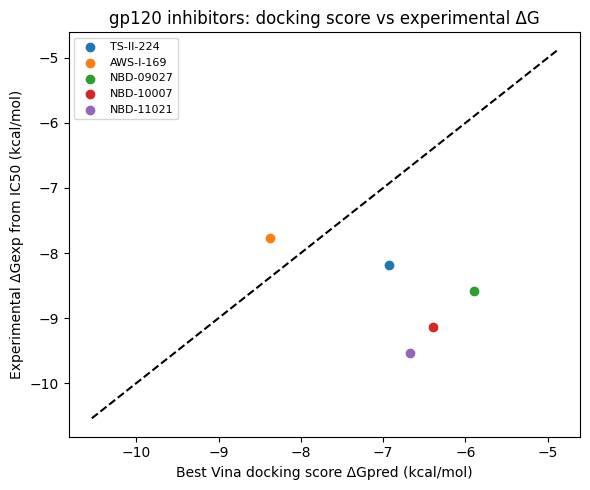

In [79]:
# @title Plot the lowest (best) docking score versus experimental ΔG for gp120 ligands
# @markdown ΔG = RT ln(IC50). Assume RT = 0.592 kcal/mol.
# @markdown IC50 values must be in molar units.

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

RT = 0.592  # kcal/mol

# gp120 project ligands
ligands = ['TS-II-224', 'AWS-I-169', 'NBD-09027', 'NBD-10007', 'NBD-11021']
receptor_codes = ['4DKO', '4DKR', '4DKU', '4DKV', '4RZ8']

# Approximate IC50 values in µM
# Replace these with exact literature values if your professor requires exact IC50s.
ic50_uM = {
    'TS-II-224': 1.0,
    'AWS-I-169': 2.0,
    'NBD-09027': 0.5,
    'NBD-10007': 0.2,
    'NBD-11021': 0.1
}

best_scores = []
dG_values = []

for ligand in ligands:

    all_scores = []

    for rec_code in receptor_codes:
        resultname = f'{rec_code}_{ligand}'
        csvfile = SUMMARY_DIR / f'{resultname}.csv'

        if not csvfile.exists():
            print(f"Missing summary file: {csvfile}")
            continue

        result = pd.read_csv(csvfile)
        all_scores += result['score (kcal/mol)'].tolist()

    print(ligand, "all_scores:", all_scores)

    if len(all_scores) == 0:
        best_scores.append(np.nan)
    else:
        best_scores.append(min(all_scores))

    # Convert µM to M
    IC50_M = ic50_uM[ligand] * 1e-6
    dG_values.append(RT * np.log(IC50_M))

print("best_scores:", best_scores)
print("dG_values:", dG_values)

# Plot
plt.figure(figsize=(6, 5))

for i, ligand in enumerate(ligands):
    plt.scatter(best_scores[i], dG_values[i], label=ligand)

# diagonal reference line
min_val = min([x for x in best_scores + dG_values if not np.isnan(x)]) - 1
max_val = max([x for x in best_scores + dG_values if not np.isnan(x)]) + 1
plt.plot([min_val, max_val], [min_val, max_val], 'k--')

plt.legend(loc='best', fontsize=8)
plt.xlabel('Best Vina docking score ΔGpred (kcal/mol)')
plt.ylabel('Experimental ΔGexp from IC50 (kcal/mol)')
plt.title('gp120 inhibitors: docking score vs experimental ΔG')
plt.tight_layout()
plt.show()

In [64]:
ligand_list = df['ligand'].tolist()
print("List of ligands:", ligand_list)

List of ligands: ['TS-II-224', 'AWS-I-169', 'NBD-09027', 'NBD-10007', 'NBD-11021']


In [80]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Convert lists to numpy arrays and reshape for sklearn
X = np.array(best_scores).reshape(-1, 1)
y = np.array(dG_values)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y, X))
mae = mean_absolute_error(y, X)
r_squared = r2_score(y, X)

print(f"Root Mean Squared Error (RMSE): {rmse:.3f} kcal/mol")
print(f"Mean Absolute Error (MAE): {mae:.3f} kcal/mol")
print(f"Coefficient of Determination (R^2): {r_squared:.3f}")

Root Mean Squared Error (RMSE): 2.234 kcal/mol
Mean Absolute Error (MAE): 2.032 kcal/mol
Coefficient of Determination (R^2): -11.291


### Plot docking score vs RMSD-to-xtal for gp120 self-docking

Coefficient of Determination (R²): 0.086
Slope (m): -0.103
Intercept (b): -1.921


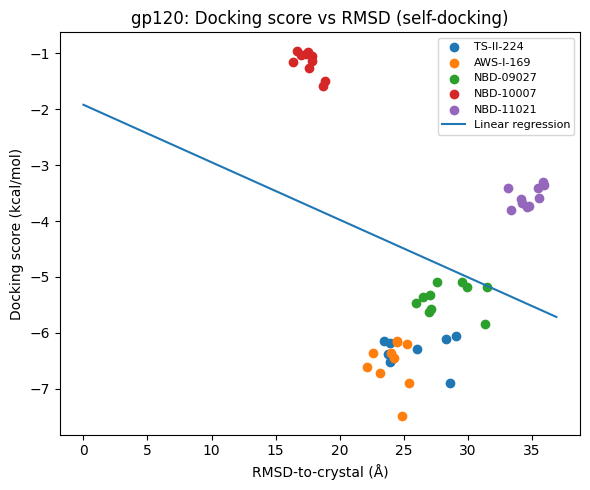

In [106]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Self-docking pairs (IMPORTANT)
ligand_rec_pairs = [
    ('TS-II-224','4DKO'),
    ('AWS-I-169','4DKR'),
    ('NBD-09027','4DKU'),
    ('NBD-10007','4DKV'),
    ('NBD-11021','4RZ8')
]

plt.figure(figsize=(6,5))

all_scores = []
all_rmsd_to_xtals = []

for ligand, rec_code in ligand_rec_pairs:

    resultname = f'{rec_code}_{ligand}'
    csvfile = SUMMARY_DIR / f'{resultname}.csv'

    if not csvfile.exists():
        print(f"❌ Missing file: {csvfile}")
        continue

    result = pd.read_csv(csvfile)

    # Remove NA values (VERY IMPORTANT)
    result = result.dropna()

    if len(result) == 0:
        print(f"⚠️ No valid RMSD data for {resultname}")
        continue

    scores = result['score (kcal/mol)'].tolist()
    rmsd_to_xtals = result['RMSD-to-xtal (A)'].tolist()

    all_scores += scores
    all_rmsd_to_xtals += rmsd_to_xtals

    plt.scatter(rmsd_to_xtals, scores, label=ligand)

# -----------------------------
# Regression (only if data exists)
# -----------------------------

if len(all_rmsd_to_xtals) > 0:

    X = np.array(all_rmsd_to_xtals).reshape(-1, 1)
    y = np.array(all_scores)

    model = LinearRegression()
    model.fit(X, y)

    # Regression line
    rmsd_range = np.linspace(0, max(all_rmsd_to_xtals)+1, 100).reshape(-1, 1)
    plt.plot(rmsd_range, model.predict(rmsd_range), label="Linear regression")

    # R²
    y_pred = model.predict(X)
    r_squared = r2_score(y, y_pred)

    print(f"Coefficient of Determination (R²): {r_squared:.3f}")
    print(f"Slope (m): {model.coef_[0]:.3f}")
    print(f"Intercept (b): {model.intercept_:.3f}")

# -----------------------------
# Plot formatting
# -----------------------------

plt.legend(loc='best', fontsize=8)
plt.xlabel('RMSD-to-crystal (Å)')
plt.ylabel('Docking score (kcal/mol)')
plt.title('gp120: Docking score vs RMSD (self-docking)')
plt.tight_layout()
plt.show()

Coefficient of Determination (R²): 0.018
Slope (m): 0.034
Intercept (b): -6.169


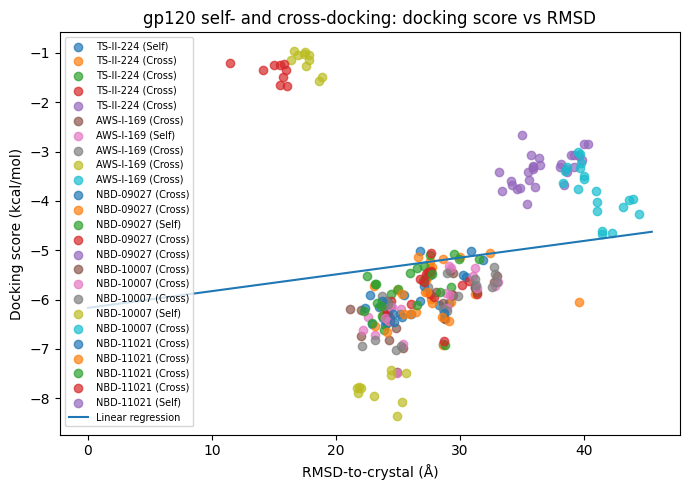

In [107]:
# @title Scatter plot INCLUDING cross-docking: docking score vs RMSD-to-xtal for gp120

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

ligands = ['TS-II-224', 'AWS-I-169', 'NBD-09027', 'NBD-10007', 'NBD-11021']
receptor_codes = ['4DKO', '4DKR', '4DKU', '4DKV', '4RZ8']

plt.figure(figsize=(7, 5))

all_scores = []
all_rmsd_to_xtals = []

for ligand in ligands:
    for rec_code in receptor_codes:

        resultname = f'{rec_code}_{ligand}'
        csvfile = SUMMARY_DIR / f'{resultname}.csv'

        if not csvfile.exists():
            print(f"❌ Missing file: {csvfile}")
            continue

        result = pd.read_csv(csvfile)

        # Convert RMSD column to numeric; "NA" becomes NaN
        result['RMSD-to-xtal (A)'] = pd.to_numeric(
            result['RMSD-to-xtal (A)'],
            errors='coerce'
        )

        # Remove rows where RMSD failed
        result = result.dropna(subset=['RMSD-to-xtal (A)', 'score (kcal/mol)'])

        if len(result) == 0:
            print(f"⚠️ No valid RMSD data for {resultname}")
            continue

        scores = result['score (kcal/mol)'].tolist()
        rmsd_to_xtals = result['RMSD-to-xtal (A)'].tolist()

        all_scores += scores
        all_rmsd_to_xtals += rmsd_to_xtals

        docking_type = "Self" if (
            (ligand == 'TS-II-224' and rec_code == '4DKO') or
            (ligand == 'AWS-I-169' and rec_code == '4DKR') or
            (ligand == 'NBD-09027' and rec_code == '4DKU') or
            (ligand == 'NBD-10007' and rec_code == '4DKV') or
            (ligand == 'NBD-11021' and rec_code == '4RZ8')
        ) else "Cross"

        plt.scatter(
            rmsd_to_xtals,
            scores,
            label=f'{ligand} ({docking_type})',
            alpha=0.7
        )

if len(all_rmsd_to_xtals) > 1:

    X = np.array(all_rmsd_to_xtals).reshape(-1, 1)
    y = np.array(all_scores)

    model = LinearRegression()
    model.fit(X, y)

    rmsd_range = np.linspace(0, max(all_rmsd_to_xtals) + 1, 100).reshape(-1, 1)
    plt.plot(rmsd_range, model.predict(rmsd_range), label="Linear regression")

    y_pred = model.predict(X)
    r_squared = r2_score(y, y_pred)

    print(f"Coefficient of Determination (R²): {r_squared:.3f}")
    print(f"Slope (m): {model.coef_[0]:.3f}")
    print(f"Intercept (b): {model.intercept_:.3f}")

else:
    print("❌ Not enough valid RMSD values for regression.")

plt.legend(loc='best', fontsize=7)
plt.xlabel('RMSD-to-crystal (Å)')
plt.ylabel('Docking score (kcal/mol)')
plt.title('gp120 self- and cross-docking: docking score vs RMSD')
plt.tight_layout()
plt.show()